# تحلیل خشکسالی با داده‌های GRACE / GRACE-FO
## فاز ۰: راه‌اندازی و بارگذاری کتابخانه‌ها

**Drought Analysis — Phase 1 (GRACE-Only)**
Thesis: *Evaluating the Strengths and Weaknesses of Drought Monitoring Based on GRACE/GRACE-FO Data*

---

This notebook implements Phase 1 of the research plan:
- Load and clean the GRACE basin TWSA data
- Compute the GRACE Drought Severity Index (GRACE-DSI) per basin
- Trend analysis (linear + Mann-Kendall)
- Temporal pattern detection (decomposition, drought episodes)
- Basin comparison
- Short-term forecasting (ARIMA + Markov chain)

All outputs are saved to the `outputs/` directory.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
import pymannkendall as mk
from pathlib import Path

# output directory — every plot goes here
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path('..')

# nice default style
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BASIN_COLORS = {
    'caspiansea':  '#1f77b4',
    'eastern':     '#ff7f0e',
    'qaraqom':     '#2ca02c',
    'markazi':     '#d62728',
    'persiangolf': '#9467bd',
    'urmia':       '#8c564b',
}

BASIN_LABELS = {
    'caspiansea':  'Caspian Sea (دریای خزر)',
    'eastern':     'Eastern (شرقی)',
    'qaraqom':     'Qaraqom (قراقوم)',
    'markazi':     'Markazi (مرکزی)',
    'persiangolf': 'Persian Gulf (خلیج فارس)',
    'urmia':       'Urmia (ارومیه)',
}

BASINS = list(BASIN_COLORS.keys())

print('Libraries loaded.')
print(f'Output directory: {OUTPUT_DIR.resolve()}')


Libraries loaded.
Output directory: E:\projects\drought_analysis\outputs


### توضیحات خروجی
<div dir="rtl">

کتابخانه‌های مورد نیاز با موفقیت بارگذاری شدند. پوشه `outputs/` برای ذخیره نمودارها آماده است.
رنگ‌بندی ثابتی برای هر حوضه تعریف شده تا همه نمودارها یکپارچه به نظر برسند.

</div>


---
## فاز ۱: بارگذاری و پاکسازی داده‌های GRACE

### Phase 1 — Data Loading & Cleaning

**GRACEbasins.xlsx** contains monthly TWSA (Total Water Storage Anomaly) values in cm
for 6 Iranian river basins, covering Aug-2002 to Dec-2022 (245 records).

Known issue: the `date` column has leading whitespace — we strip it before parsing.


In [2]:
# Load the GRACE data
grace_raw = pd.read_excel(DATA_DIR / 'GRACEbasins.xlsx', engine='openpyxl')

print('Raw shape:', grace_raw.shape)
print('\nFirst 3 rows:')
print(grace_raw.head(3))
print('\nColumn dtypes:')
print(grace_raw.dtypes)
print('\nDate sample (before strip):', repr(grace_raw['date'].iloc[0]))


Raw shape: (245, 7)

First 3 rows:
          date  caspiansea  eastern  qaraqom  markazi  persiangolf  urmia
0     Aug-2002       1.688    6.913    8.560    3.029        1.741 -0.159
1     Sep-2002      -1.827    4.546   -0.483   -3.575        0.813 -3.464
2     Oct-2002       0.274    2.290    2.434    2.625        3.379  1.068

Column dtypes:
date               str
caspiansea     float64
eastern        float64
qaraqom        float64
markazi        float64
persiangolf    float64
urmia          float64
dtype: object

Date sample (before strip): '   Aug-2002'


In [3]:
# Fix leading whitespace in date, then parse
grace_raw['date'] = grace_raw['date'].str.strip()
grace_raw['date'] = pd.to_datetime(grace_raw['date'], format='%b-%Y')

# Set date as index and sort
grace = grace_raw.set_index('date').sort_index()

# Convert all basin columns to float (they came in as strings)
grace = grace.apply(pd.to_numeric, errors='coerce')

print('Parsed date range:', grace.index.min(), '→', grace.index.max())
print('Total months:', len(grace))
print('\nMissing values per basin:')
print(grace.isna().sum())


Parsed date range: 2002-08-01 00:00:00 → 2022-12-01 00:00:00
Total months: 245

Missing values per basin:
caspiansea     0
eastern        0
qaraqom        0
markazi        0
persiangolf    0
urmia          0
dtype: int64


In [4]:
# Quick overview of the data
print('TWSA statistics per basin (cm):')
stats_df = grace.describe().T
stats_df.index.name = 'basin'
print(stats_df.round(2))

# Save cleaned data
grace.to_csv(OUTPUT_DIR / 'grace_cleaned.csv')
print('\nCleaned data saved to outputs/grace_cleaned.csv')


TWSA statistics per basin (cm):
             count  mean    std    min    25%   50%   75%    max
basin                                                           
caspiansea   245.0 -6.44  13.45 -42.91 -16.02 -5.86  4.44  18.19
eastern      245.0 -1.12   4.30 -15.65  -3.66 -1.06  1.55  20.47
qaraqom      245.0 -0.53   5.08 -14.28  -3.80 -0.81  2.85  15.62
markazi      245.0 -2.09   5.75 -17.61  -6.62 -2.40  1.95  13.29
persiangolf  245.0 -1.09   6.97 -16.23  -6.47 -1.74  2.77  17.00
urmia        245.0 -2.40  11.17 -30.08 -10.94 -2.64  4.64  24.56

Cleaned data saved to outputs/grace_cleaned.csv


### توضیحات خروجی
<div dir="rtl">

داده‌های GRACE با موفقیت بارگذاری و پاکسازی شدند.
- بازه زمانی: مرداد ۱۳۸۱ تا دی ۱۴۰۱ (۲۴۵ ماه)
- ۶ حوضه آبریز: دریای خزر، شرقی، قراقوم، مرکزی، خلیج فارس، ارومیه
- مقادیر TWSA بر حسب سانتی‌متر (ناهنجاری ذخیره آب کل)
- داده‌های پاکسازی‌شده در `outputs/grace_cleaned.csv` ذخیره شدند

</div>


---
## فاز ۲: محاسبه شاخص خشکسالی GRACE (GRACE-DSI)

### Phase 2 — GRACE Drought Severity Index

We standardize each basin's TWSA to a z-score, giving the **GRACE-DSI**:

```
GRACE-DSI(t) = (TWSA(t) − mean(TWSA)) / std(TWSA)
```

Drought classification:
| DSI | Category |
|-----|----------|
| DSI ≥ 0 | No drought |
| −1.0 ≤ DSI < 0 | Near-normal |
| −1.5 ≤ DSI < −1.0 | Moderate drought |
| −2.0 ≤ DSI < −1.5 | Severe drought |
| DSI < −2.0 | Extreme drought |


In [5]:
# Calculate GRACE-DSI (z-score of TWSA) per basin
dsi = (grace - grace.mean()) / grace.std()

def classify_dsi(val):
    if pd.isna(val): return 'Unknown'
    if val >= 0:      return 'No drought'
    if val >= -1.0:   return 'Near-normal'
    if val >= -1.5:   return 'Moderate'
    if val >= -2.0:   return 'Severe'
    return 'Extreme'

print('GRACE-DSI stats per basin:')
print(dsi.describe().T.round(3))

# Count drought months per basin
print('\nMonths in each drought class per basin:')
for basin in BASINS:
    classes = dsi[basin].apply(classify_dsi).value_counts()
    print(f'  {BASIN_LABELS[basin]}:')
    for cat, cnt in classes.items():
        print(f'    {cat}: {cnt}')

dsi.to_csv(OUTPUT_DIR / 'grace_dsi.csv')
print('\nGRACE-DSI saved to outputs/grace_dsi.csv')


GRACE-DSI stats per basin:
             count  mean  std    min    25%    50%    75%    max
caspiansea   245.0   0.0  1.0 -2.712 -0.713  0.043  0.809  1.832
eastern      245.0   0.0  1.0 -3.380 -0.591  0.014  0.620  5.021
qaraqom      245.0   0.0  1.0 -2.704 -0.644 -0.055  0.665  3.176
markazi      245.0   0.0  1.0 -2.697 -0.787 -0.055  0.701  2.672
persiangolf  245.0  -0.0  1.0 -2.171 -0.772 -0.093  0.554  2.595
urmia        245.0   0.0  1.0 -2.479 -0.765 -0.022  0.630  2.414

Months in each drought class per basin:
  Caspian Sea (دریای خزر):
    No drought: 125
    Near-normal: 78
    Moderate: 26
    Severe: 10
    Extreme: 6
  Eastern (شرقی):
    No drought: 125
    Near-normal: 86
    Moderate: 17
    Severe: 12
    Extreme: 5
  Qaraqom (قراقوم):
    No drought: 119
    Near-normal: 94
    Moderate: 17
    Severe: 8
    Extreme: 7
  Markazi (مرکزی):
    No drought: 118
    Near-normal: 86
    Moderate: 29
    Severe: 9
    Extreme: 3
  Persian Gulf (خلیج فارس):
    No drought: 115

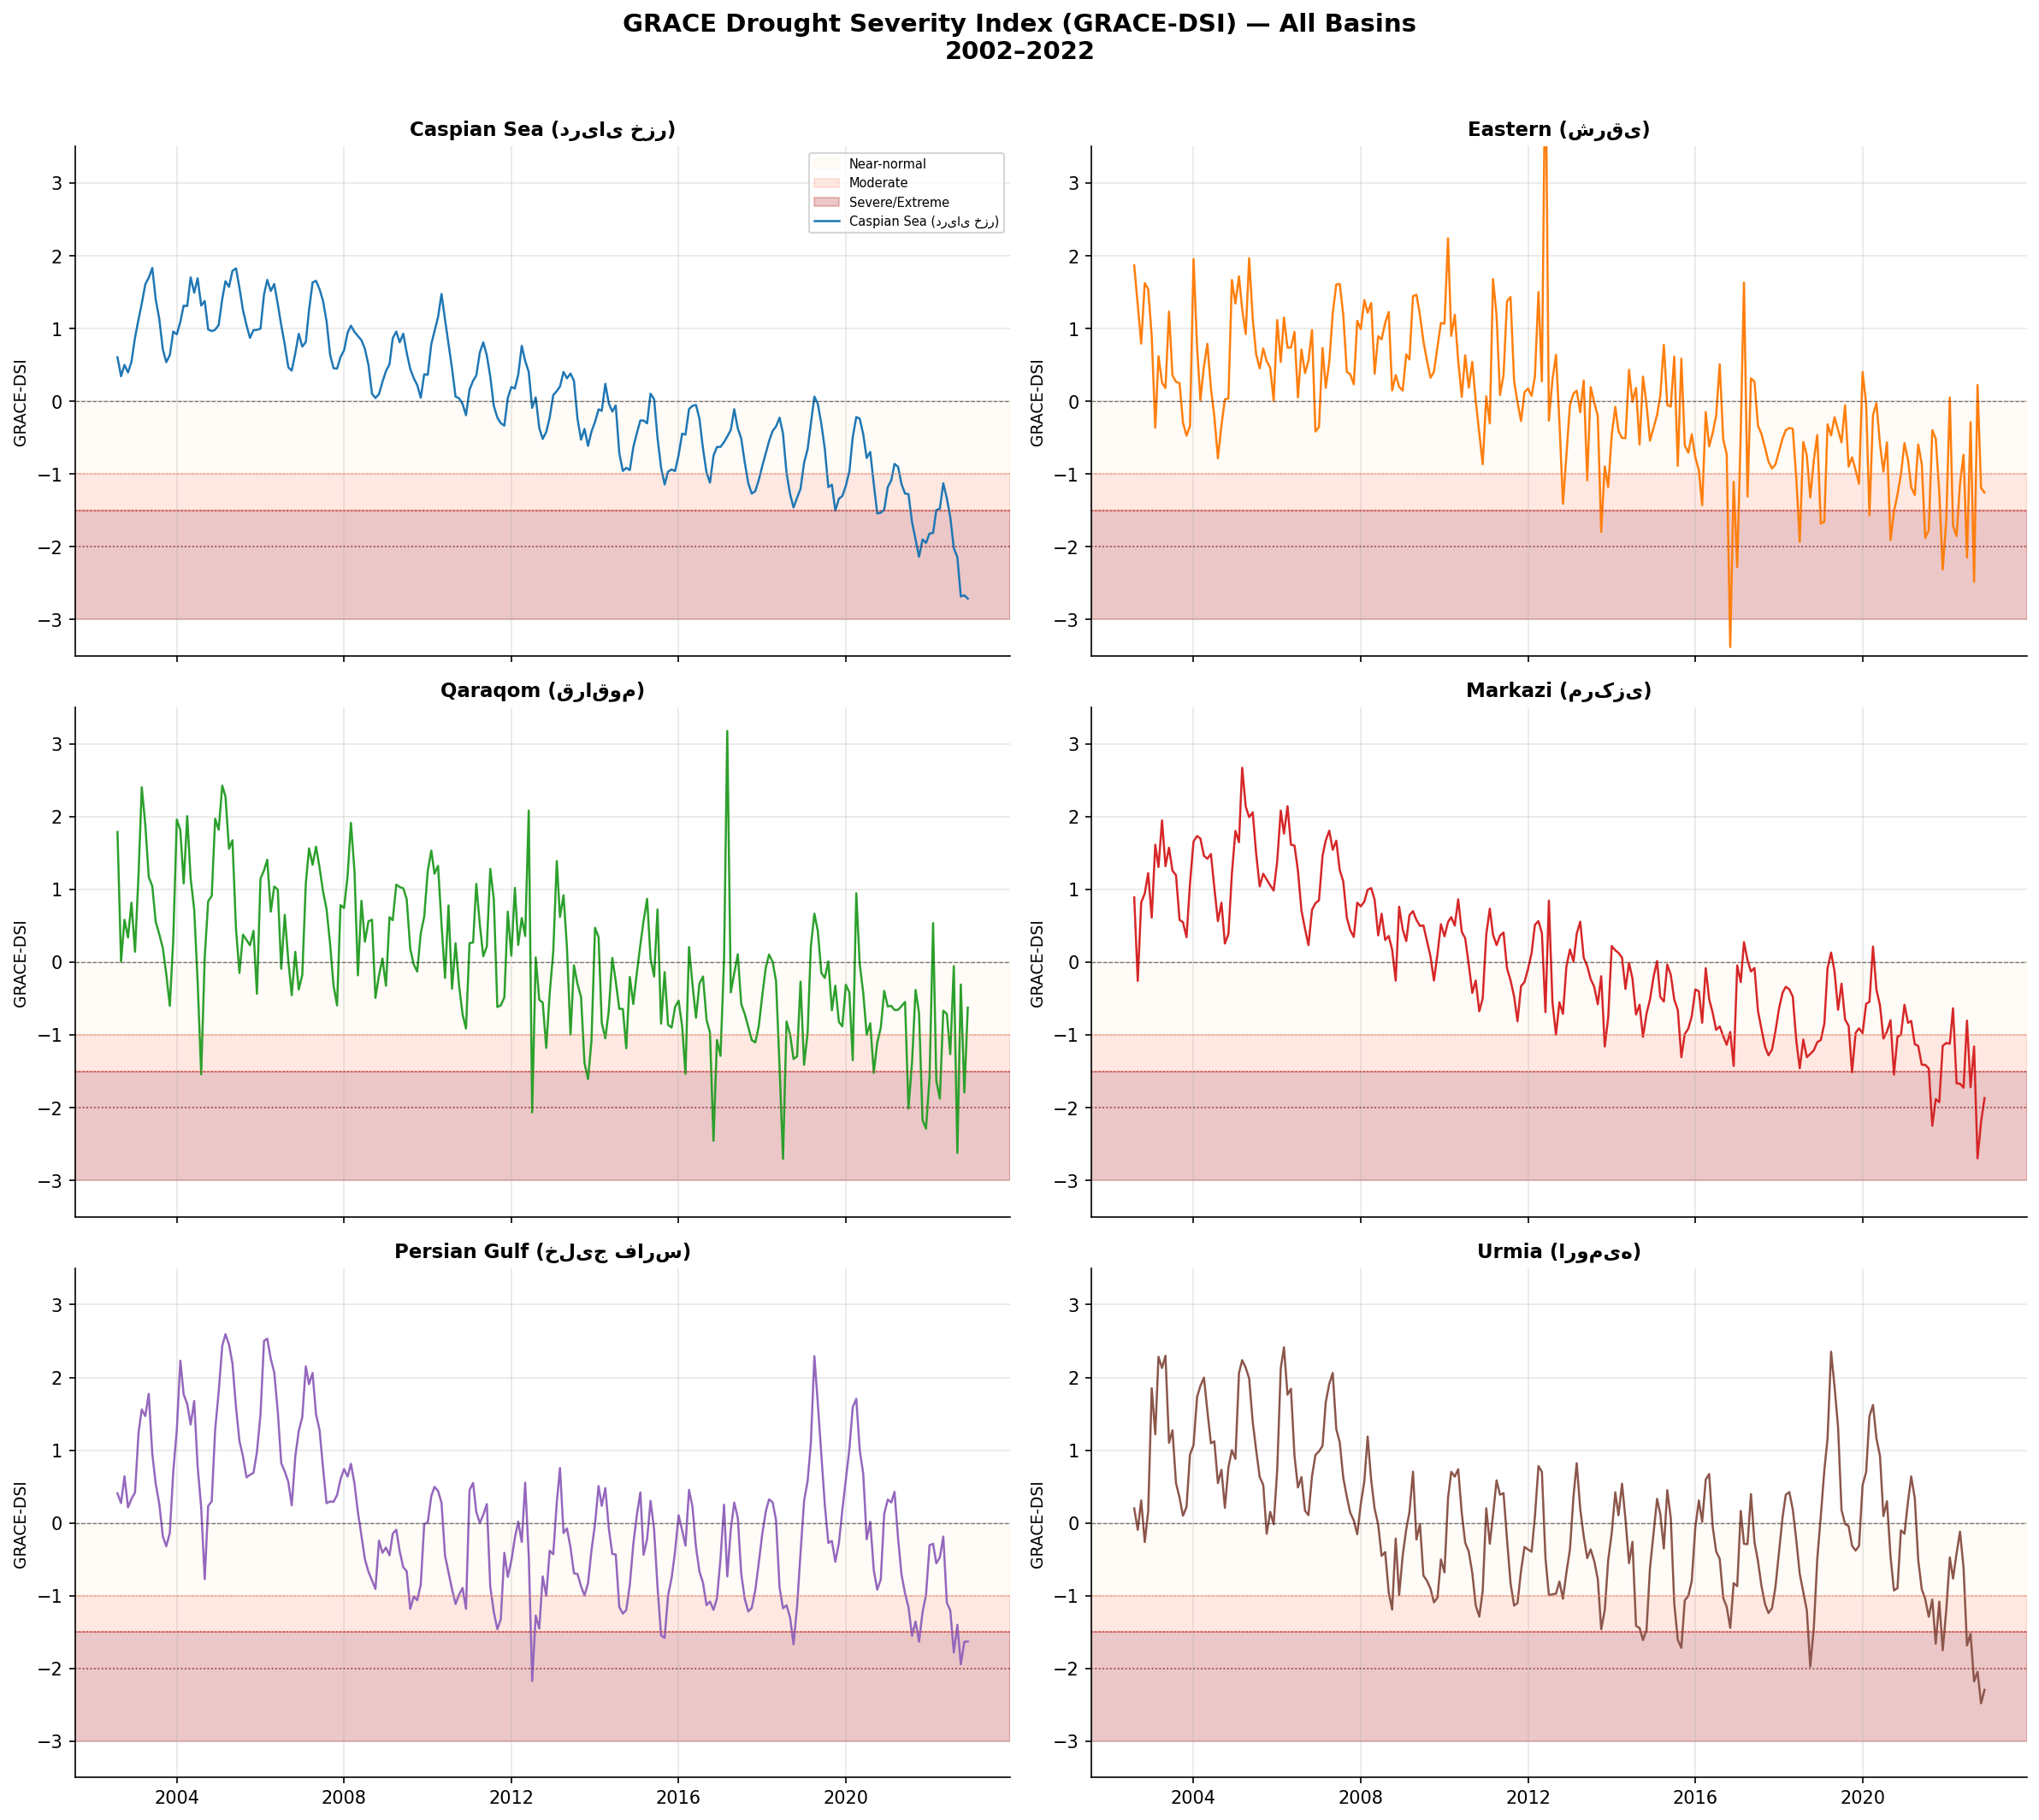

Plot saved: outputs/grace_dsi_all_basins.png


In [6]:
# Plot GRACE-DSI for all basins (one subplot per basin)
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

drought_thresholds = [0, -1.0, -1.5, -2.0]
fill_colors = ['#e8f4f8', '#ffe4b5', '#ff8c69', '#b22222']
labels_th   = ['Normal/Wet', 'Near-normal', 'Moderate', 'Severe/Extreme']

for idx, basin in enumerate(BASINS):
    ax = axes[idx]
    series = dsi[basin]

    # Shade drought severity bands
    ax.axhspan(-1.0, 0,    alpha=0.12, color='#ffe4b5', label='Near-normal')
    ax.axhspan(-1.5, -1.0, alpha=0.20, color='#ff8c69', label='Moderate')
    ax.axhspan(-3.0, -1.5, alpha=0.25, color='#b22222', label='Severe/Extreme')

    ax.plot(series.index, series.values, color=BASIN_COLORS[basin],
            linewidth=1.2, label=BASIN_LABELS[basin])
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.axhline(-1.0, color='#ff8c69', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.axhline(-1.5, color='#b22222', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.axhline(-2.0, color='#8b0000', linewidth=0.8, linestyle=':', alpha=0.7)

    ax.set_title(BASIN_LABELS[basin], fontsize=11, fontweight='bold')
    ax.set_ylabel('GRACE-DSI', fontsize=9)
    ax.set_ylim(-3.5, 3.5)

    # Only add legend to first subplot
    if idx == 0:
        ax.legend(fontsize=7, loc='upper right')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))

fig.suptitle('GRACE Drought Severity Index (GRACE-DSI) — All Basins\n2002–2022',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'grace_dsi_all_basins.png', bbox_inches='tight', dpi=300)
plt.show()
print('Plot saved: outputs/grace_dsi_all_basins.png')


### توضیحات خروجی
<div dir="rtl">

نمودار GRACE-DSI برای هر ۶ حوضه رسم شد. نکات مهم:
- مقادیر زیر صفر نشان‌دهنده خشکسالی هستند
- نوارهای رنگی سطوح مختلف خشکسالی (خفیف، متوسط، شدید) را نشان می‌دهند
- حوضه‌هایی که DSI مکرراً زیر ۱.۵- قرار می‌گیرد نیاز به توجه بیشتری دارند

</div>


---
## فاز ۳: تحلیل روند TWSA

### Phase 3 — Trend Analysis (Linear + Mann-Kendall)

We test whether each basin's water storage is trending up or down over 2002–2022.

Two methods:
1. **Linear regression** — gives slope (cm/year) and statistical significance
2. **Mann-Kendall test** — non-parametric, robust to non-normal residuals; gives Kendall's τ and p-value


In [7]:
# Trend analysis per basin
trend_results = []

# Convert the date index to a numeric "months since start" for regression
months_num = np.arange(len(grace))

for basin in BASINS:
    y = grace[basin].values

    # Linear regression
    slope, intercept, r_val, p_val, se = stats.linregress(months_num, y)
    slope_per_year = slope * 12  # convert monthly slope to annual

    # Mann-Kendall test
    mk_result = mk.original_test(y)

    trend_results.append({
        'Basin': BASIN_LABELS[basin],
        'Slope (cm/yr)': round(slope_per_year, 3),
        'R²': round(r_val**2, 3),
        'OLS p-value': round(p_val, 4),
        'OLS significance': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns')),
        'MK trend': mk_result.trend,
        'MK τ': round(mk_result.Tau, 3),
        'MK p-value': round(mk_result.p, 4),
        'MK significance': '***' if mk_result.p < 0.001 else ('**' if mk_result.p < 0.01 else ('*' if mk_result.p < 0.05 else 'ns')),
    })

trend_df = pd.DataFrame(trend_results)
print('Trend Analysis Results:')
print(trend_df.to_string(index=False))

trend_df.to_csv(OUTPUT_DIR / 'trend_analysis.csv', index=False)
print('\nSaved to outputs/trend_analysis.csv')


Trend Analysis Results:
                   Basin  Slope (cm/yr)    R²  OLS p-value OLS significance   MK trend   MK τ  MK p-value MK significance
 Caspian Sea (دریای خزر)         -2.043 0.805          0.0              *** decreasing -0.724         0.0             ***
          Eastern (شرقی)         -0.472 0.420          0.0              *** decreasing -0.507         0.0             ***
        Qaraqom (قراقوم)         -0.535 0.387          0.0              *** decreasing -0.458         0.0             ***
         Markazi (مرکزی)         -0.840 0.744          0.0              *** decreasing -0.683         0.0             ***
Persian Gulf (خلیج فارس)         -0.602 0.260          0.0              *** decreasing -0.351         0.0             ***
          Urmia (ارومیه)         -0.977 0.267          0.0              *** decreasing -0.359         0.0             ***

Saved to outputs/trend_analysis.csv


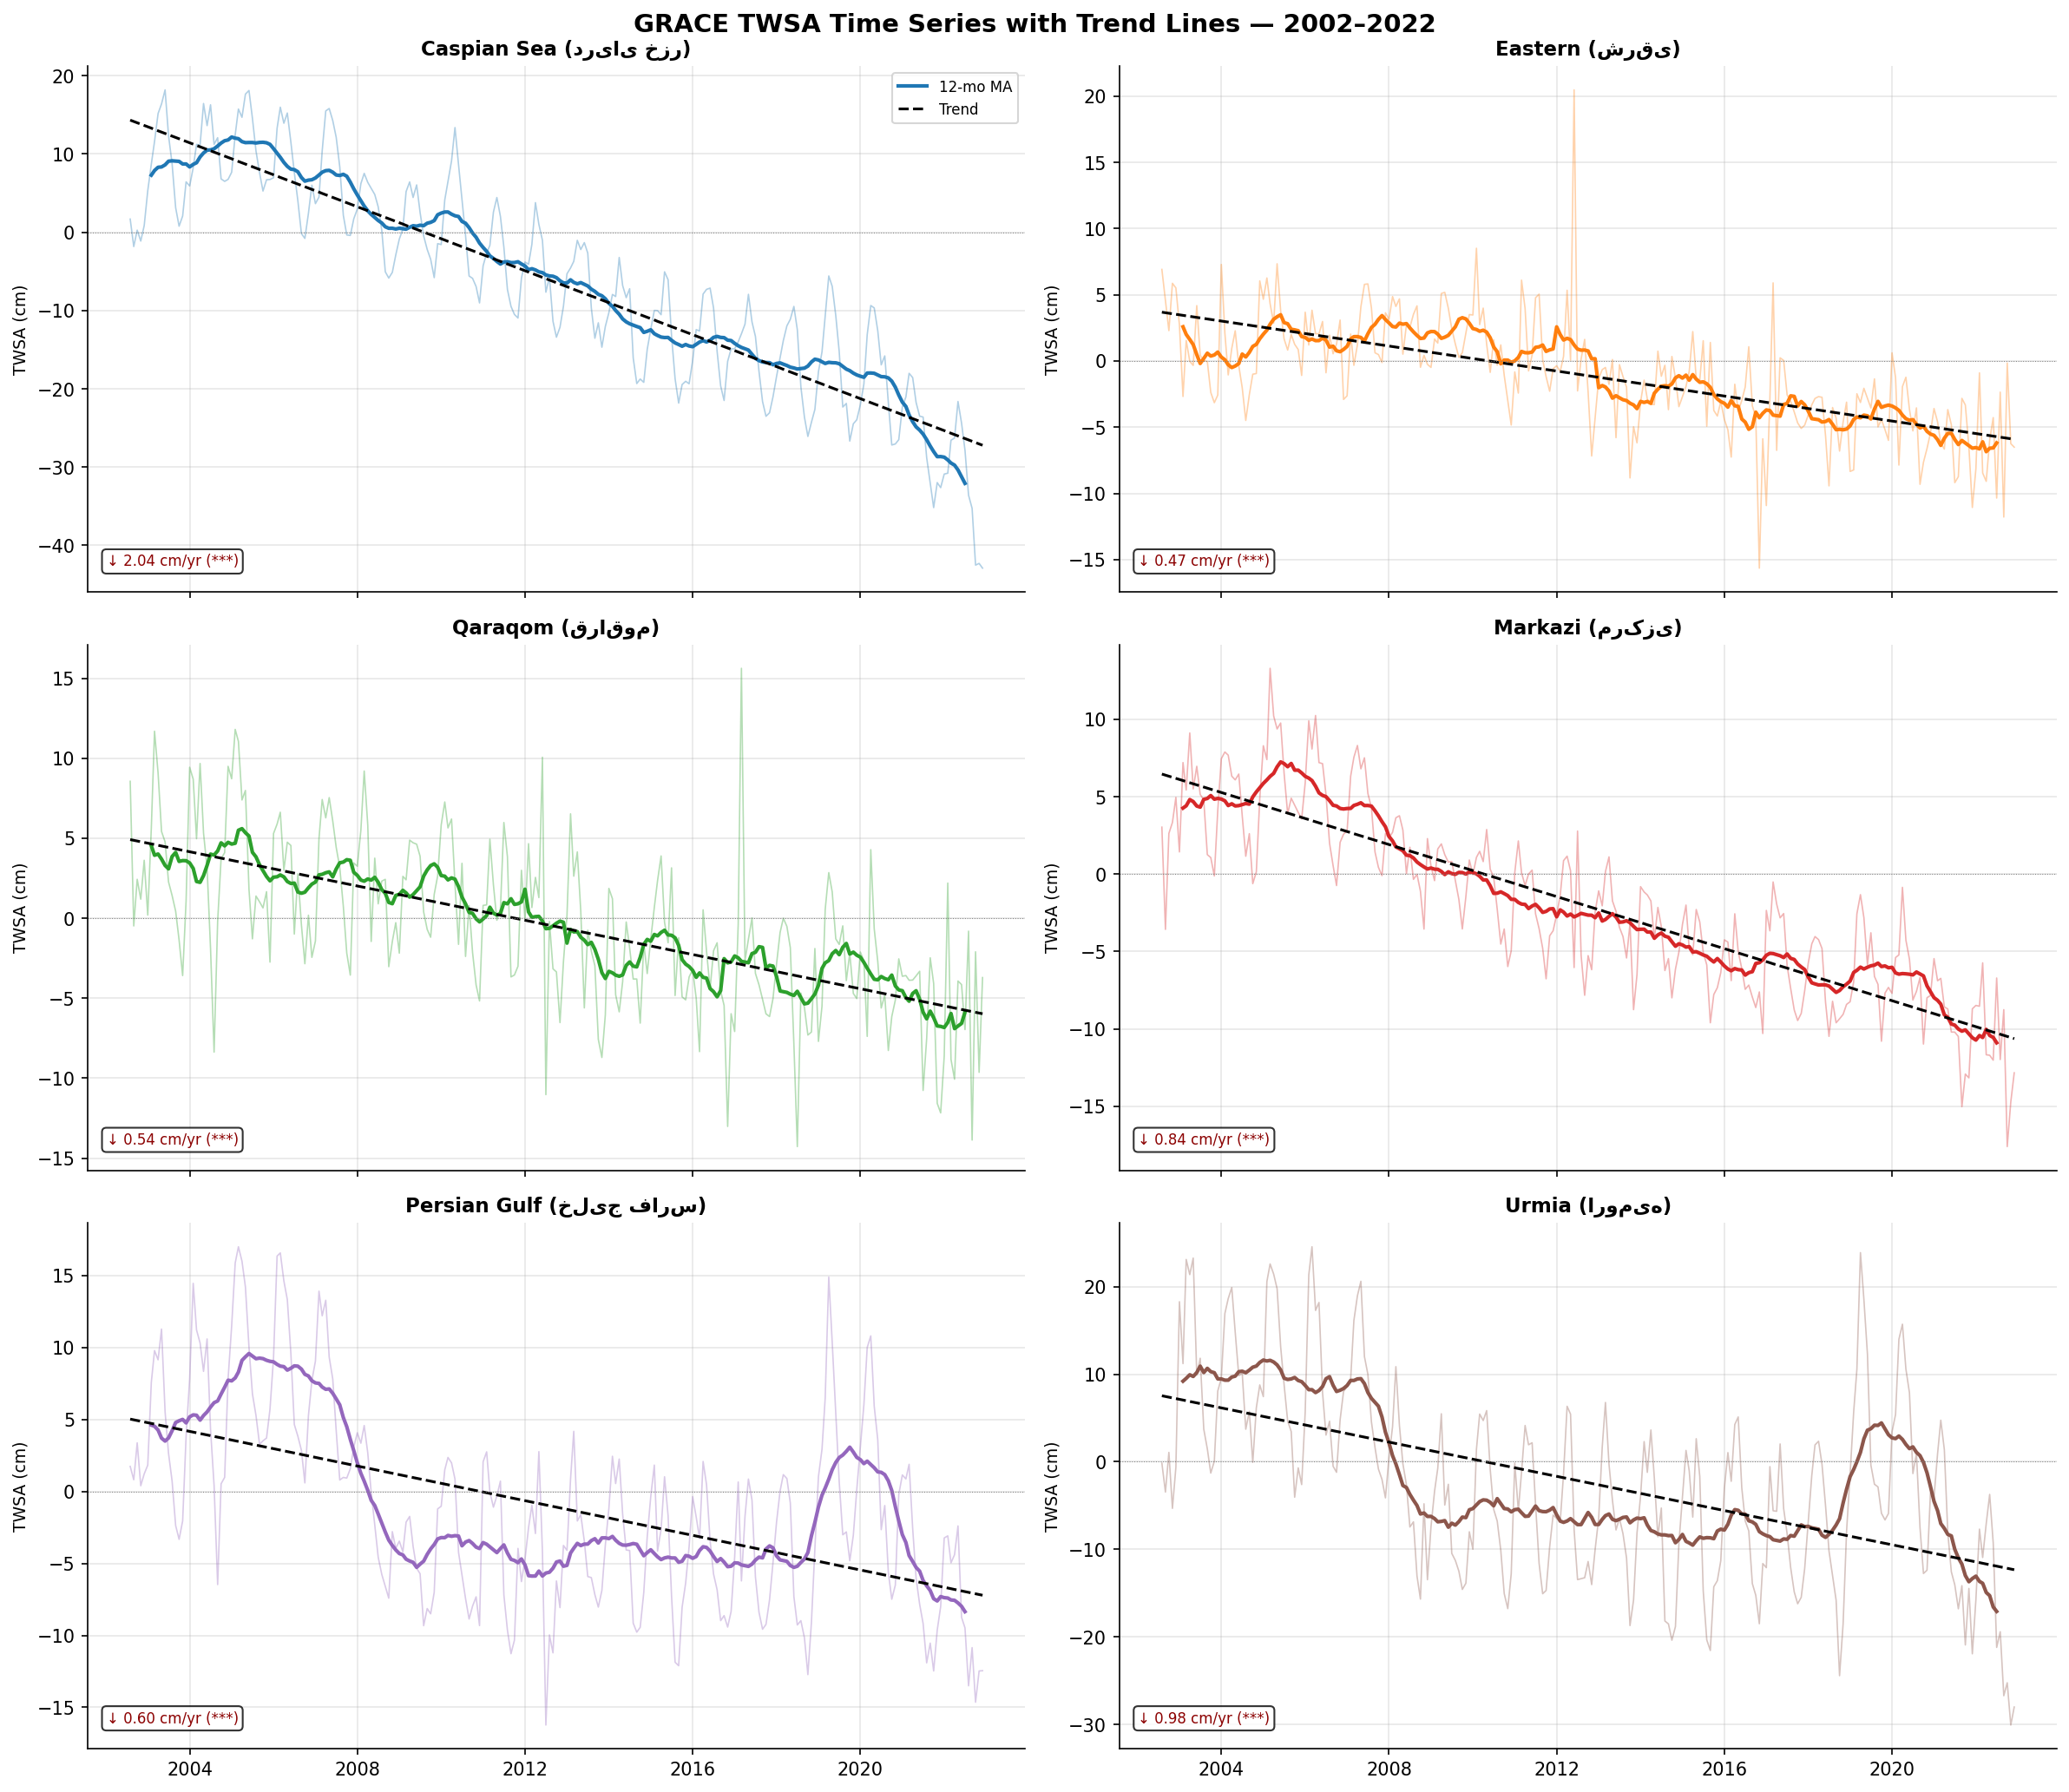

Plot saved: outputs/grace_twsa_trends.png


In [8]:
# Plot TWSA time series with trend lines
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for idx, basin in enumerate(BASINS):
    ax = axes[idx]
    y = grace[basin].values
    x_dates = grace.index

    # 12-month moving average
    ma12 = grace[basin].rolling(12, center=True).mean()

    ax.plot(x_dates, y, color=BASIN_COLORS[basin], alpha=0.35, linewidth=0.8)
    ax.plot(x_dates, ma12, color=BASIN_COLORS[basin], linewidth=2.0, label='12-mo MA')

    # Add trend line
    slope, intercept, *_ = stats.linregress(months_num, y)
    trend_line = intercept + slope * months_num
    ax.plot(x_dates, trend_line, color='black', linewidth=1.5,
            linestyle='--', label='Trend')

    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.set_title(BASIN_LABELS[basin], fontsize=11, fontweight='bold')
    ax.set_ylabel('TWSA (cm)', fontsize=9)

    slope_yr = slope * 12
    row = trend_df[trend_df['Basin'] == BASIN_LABELS[basin]].iloc[0]
    direction = '↓' if slope_yr < 0 else '↑'
    ax.annotate(f"{direction} {abs(slope_yr):.2f} cm/yr ({row['MK significance']})",
                xy=(0.02, 0.05), xycoords='axes fraction', fontsize=8,
                color='darkred' if slope_yr < 0 else 'darkgreen',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    if idx == 0:
        ax.legend(fontsize=8)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))

fig.suptitle('GRACE TWSA Time Series with Trend Lines — 2002–2022',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'grace_twsa_trends.png', bbox_inches='tight', dpi=300)
plt.show()
print('Plot saved: outputs/grace_twsa_trends.png')


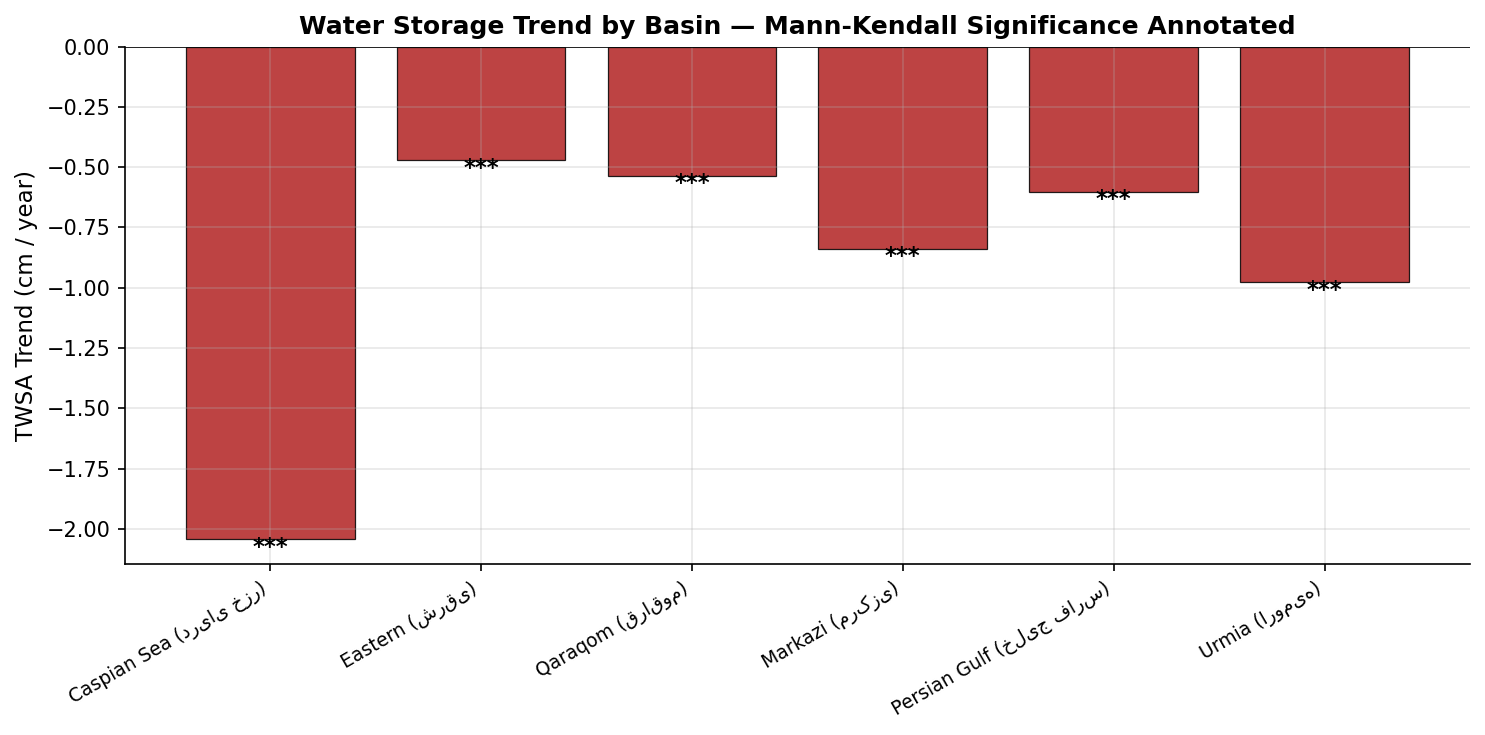

Plot saved: outputs/trend_summary_bars.png


In [9]:
# Summary bar chart: slope per basin
fig, ax = plt.subplots(figsize=(10, 5))

slopes = trend_df.set_index('Basin')['Slope (cm/yr)']
sig    = trend_df.set_index('Basin')['MK significance']
colors = ['#b22222' if s < 0 else '#2ca02c' for s in slopes]

bars = ax.bar(range(len(slopes)), slopes.values, color=colors, edgecolor='black',
              linewidth=0.6, alpha=0.85)

ax.set_xticks(range(len(slopes)))
ax.set_xticklabels(slopes.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('TWSA Trend (cm / year)', fontsize=11)
ax.set_title('Water Storage Trend by Basin — Mann-Kendall Significance Annotated',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)

for i, (bar, s) in enumerate(zip(bars, sig.values)):
    ypos = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.08
    ax.text(i, ypos, s, ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'trend_summary_bars.png', bbox_inches='tight', dpi=300)
plt.show()
print('Plot saved: outputs/trend_summary_bars.png')


### توضیحات خروجی
<div dir="rtl">

نتایج تحلیل روند نشان می‌دهد:
- حوضه‌هایی با شیب منفی قابل توجه (ستون‌های قرمز) در حال از دست دادن ذخایر آب هستند — این نشانه جدی تشدید خشکسالی است.
- آزمون من-کندال (غیرپارامتری) روند را بدون فرض نرمال‌بودن داده‌ها تأیید می‌کند.
- ستاره‌های معناداری: `***` p < 0.001، `**` p < 0.01، `*` p < 0.05، `ns` = غیرمعنادار

</div>


---
## فاز ۴: تشخیص الگوهای زمانی خشکسالی

### Phase 4 — Temporal Pattern Detection

Three tools here:
1. **Seasonal decomposition** — separates seasonality, trend, and residual noise
2. **Drought episode detection** — finds continuous runs of DSI < −1.0
3. **Drought frequency table** — counts severe/extreme events per decade


In [10]:
# Seasonal decomposition — run for each basin and save the most interesting one
# (we'll show all in a combined figure)
decomp_results = {}

for basin in BASINS:
    series = grace[basin].dropna()
    # Need at least 2 full cycles for decomposition
    if len(series) >= 24:
        result = seasonal_decompose(series, model='additive', period=12, extrapolate_trend='freq')
        decomp_results[basin] = result

print(f'Decomposition complete for {len(decomp_results)} basins.')


Decomposition complete for 6 basins.


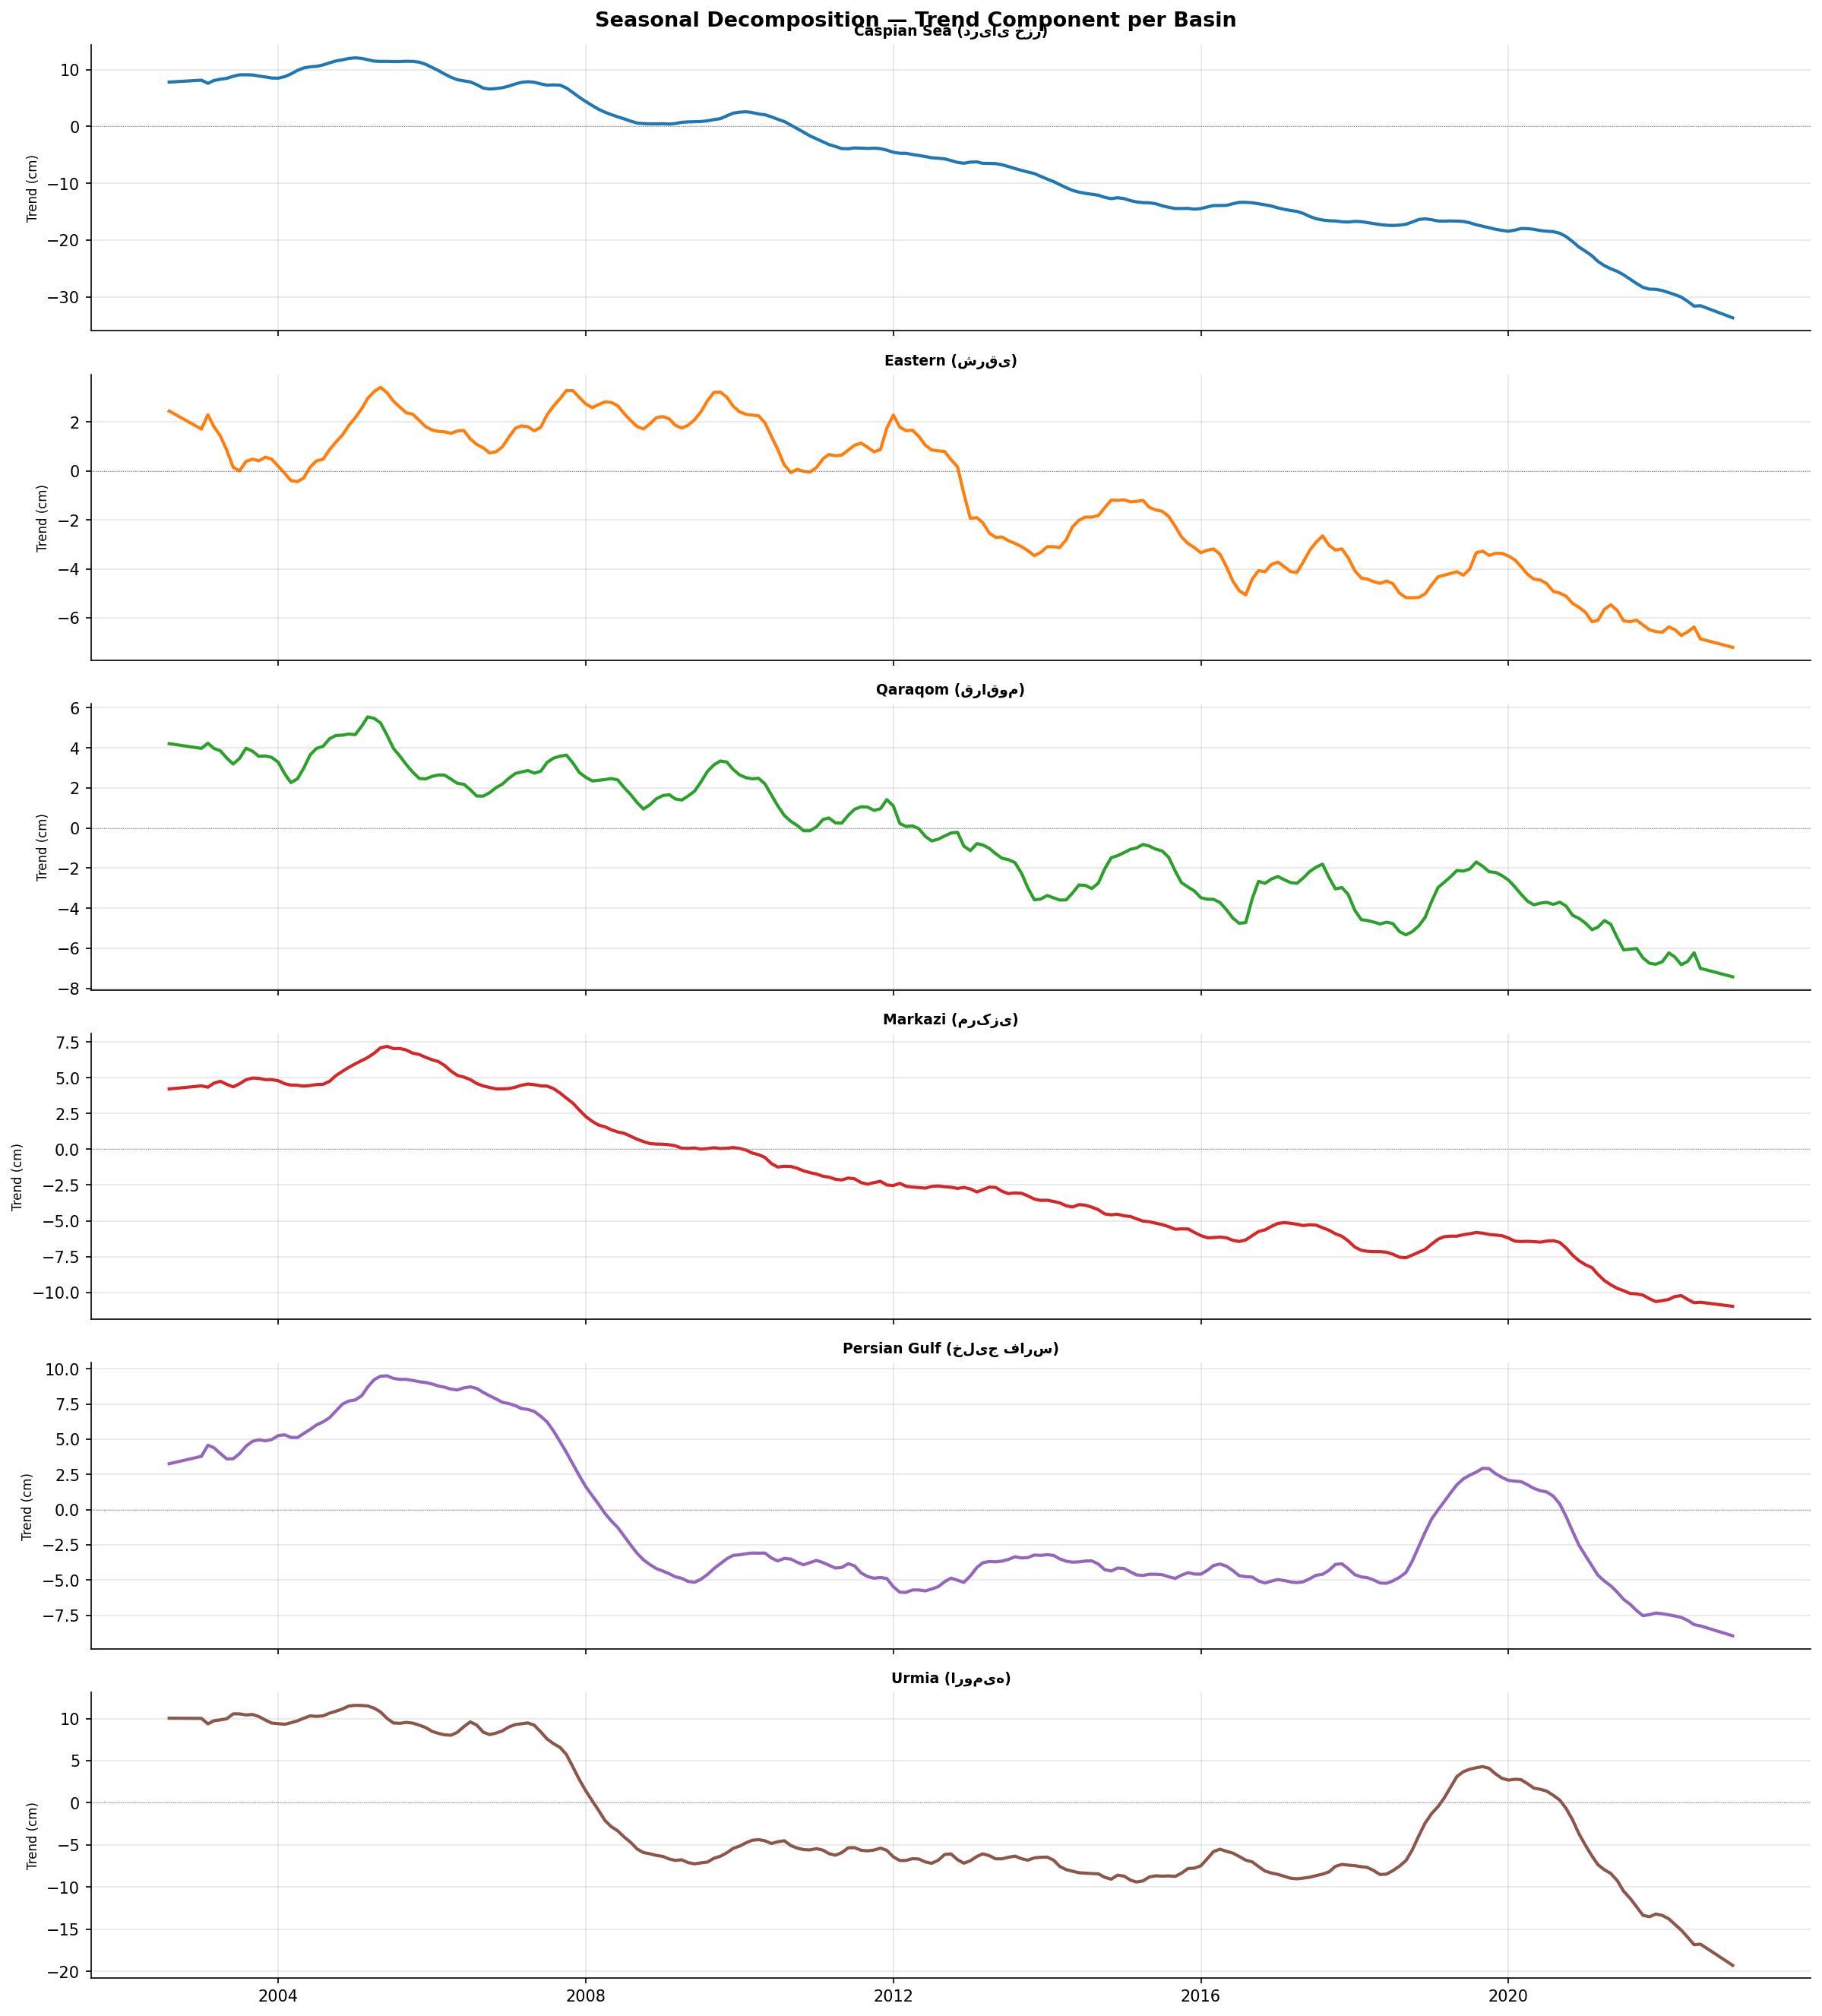

Plot saved: outputs/decomposition_trends.png


In [11]:
# Plot decomposition for all basins — trend component tells the story
fig, axes = plt.subplots(len(BASINS), 1, figsize=(16, 18), sharex=True)

for idx, basin in enumerate(BASINS):
    ax = axes[idx]
    r = decomp_results[basin]
    ax.plot(r.trend.index, r.trend.values, color=BASIN_COLORS[basin], linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.set_ylabel('Trend (cm)', fontsize=8)
    ax.set_title(BASIN_LABELS[basin], fontsize=9, fontweight='bold')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))

fig.suptitle('Seasonal Decomposition — Trend Component per Basin',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'decomposition_trends.png', bbox_inches='tight', dpi=300)
plt.show()
print('Plot saved: outputs/decomposition_trends.png')


In [12]:
# Drought episode detection:
# A drought episode = consecutive months with DSI < -1.0
def find_drought_episodes(dsi_series, threshold=-1.0):
    episodes = []
    in_drought = False
    start = None
    for date, val in dsi_series.items():
        if not pd.isna(val) and val < threshold:
            if not in_drought:
                in_drought = True
                start = date
        else:
            if in_drought:
                in_drought = False
                duration = (date.year - start.year) * 12 + (date.month - start.month)
                min_val = dsi_series[start:date].min()
                episodes.append({
                    'start': start.strftime('%Y-%m'),
                    'end': date.strftime('%Y-%m'),
                    'duration_months': duration,
                    'min_DSI': round(min_val, 2),
                })
    # Handle drought still ongoing at end of series
    if in_drought:
        duration = (dsi_series.index[-1].year - start.year) * 12 + (dsi_series.index[-1].month - start.month) + 1
        episodes.append({
            'start': start.strftime('%Y-%m'),
            'end': dsi_series.index[-1].strftime('%Y-%m') + ' (ongoing)',
            'duration_months': duration,
            'min_DSI': round(dsi_series[start:].min(), 2),
        })
    return episodes

all_episodes = {}
for basin in BASINS:
    eps = find_drought_episodes(dsi[basin])
    all_episodes[basin] = eps
    print(f'\n{BASIN_LABELS[basin]} — {len(eps)} drought episodes (DSI < -1.0):')
    for ep in eps:
        print(f'  {ep["start"]} → {ep["end"]}  |  {ep["duration_months"]} months  |  min DSI: {ep["min_DSI"]}')



Caspian Sea (دریای خزر) — 7 drought episodes (DSI < -1.0):
  2015-09 → 2015-10  |  1 months  |  min DSI: -1.14
  2016-10 → 2016-11  |  1 months  |  min DSI: -1.12
  2017-09 → 2018-01  |  4 months  |  min DSI: -1.27
  2018-09 → 2019-01  |  4 months  |  min DSI: -1.46
  2019-08 → 2020-02  |  6 months  |  min DSI: -1.5
  2020-09 → 2021-03  |  6 months  |  min DSI: -1.54
  2021-05 → 2022-12 (ongoing)  |  20 months  |  min DSI: -2.71

Eastern (شرقی) — 20 drought episodes (DSI < -1.0):
  2012-11 → 2012-12  |  1 months  |  min DSI: -1.41
  2013-06 → 2013-07  |  1 months  |  min DSI: -1.09
  2013-10 → 2013-11  |  1 months  |  min DSI: -1.8
  2013-12 → 2014-01  |  1 months  |  min DSI: -1.18
  2016-03 → 2016-04  |  1 months  |  min DSI: -1.43
  2016-11 → 2017-02  |  3 months  |  min DSI: -3.38
  2017-04 → 2017-05  |  1 months  |  min DSI: -1.31
  2018-06 → 2018-08  |  2 months  |  min DSI: -1.93
  2018-10 → 2018-11  |  1 months  |  min DSI: -1.32
  2019-01 → 2019-03  |  2 months  |  min DSI: -

In [13]:
# Summary: total drought months and longest episode per basin
summary_rows = []
for basin in BASINS:
    eps = all_episodes[basin]
    if eps:
        total_months  = sum(e['duration_months'] for e in eps)
        longest       = max(eps, key=lambda e: e['duration_months'])
        worst_dsi     = min(e['min_DSI'] for e in eps)
    else:
        total_months, worst_dsi = 0, 0.0
        longest = {'duration_months': 0, 'start': 'N/A', 'end': 'N/A'}
    summary_rows.append({
        'Basin': BASIN_LABELS[basin],
        'Episodes': len(eps),
        'Total drought months': total_months,
        'Longest episode (mo)': longest['duration_months'],
        'Worst DSI': worst_dsi,
    })

ep_summary = pd.DataFrame(summary_rows)
print('Drought Episode Summary:')
print(ep_summary.to_string(index=False))

ep_summary.to_csv(OUTPUT_DIR / 'drought_episodes.csv', index=False)
print('\nSaved to outputs/drought_episodes.csv')


Drought Episode Summary:
                   Basin  Episodes  Total drought months  Longest episode (mo)  Worst DSI
 Caspian Sea (دریای خزر)         7                    42                    20      -2.71
          Eastern (شرقی)        20                    34                     4      -3.38
        Qaraqom (قراقوم)        20                    32                     3      -2.70
         Markazi (مرکزی)        13                    41                    11      -2.70
Persian Gulf (خلیج فارس)        13                    41                     7      -2.17
          Urmia (ارومیه)        13                    41                     7      -2.48

Saved to outputs/drought_episodes.csv


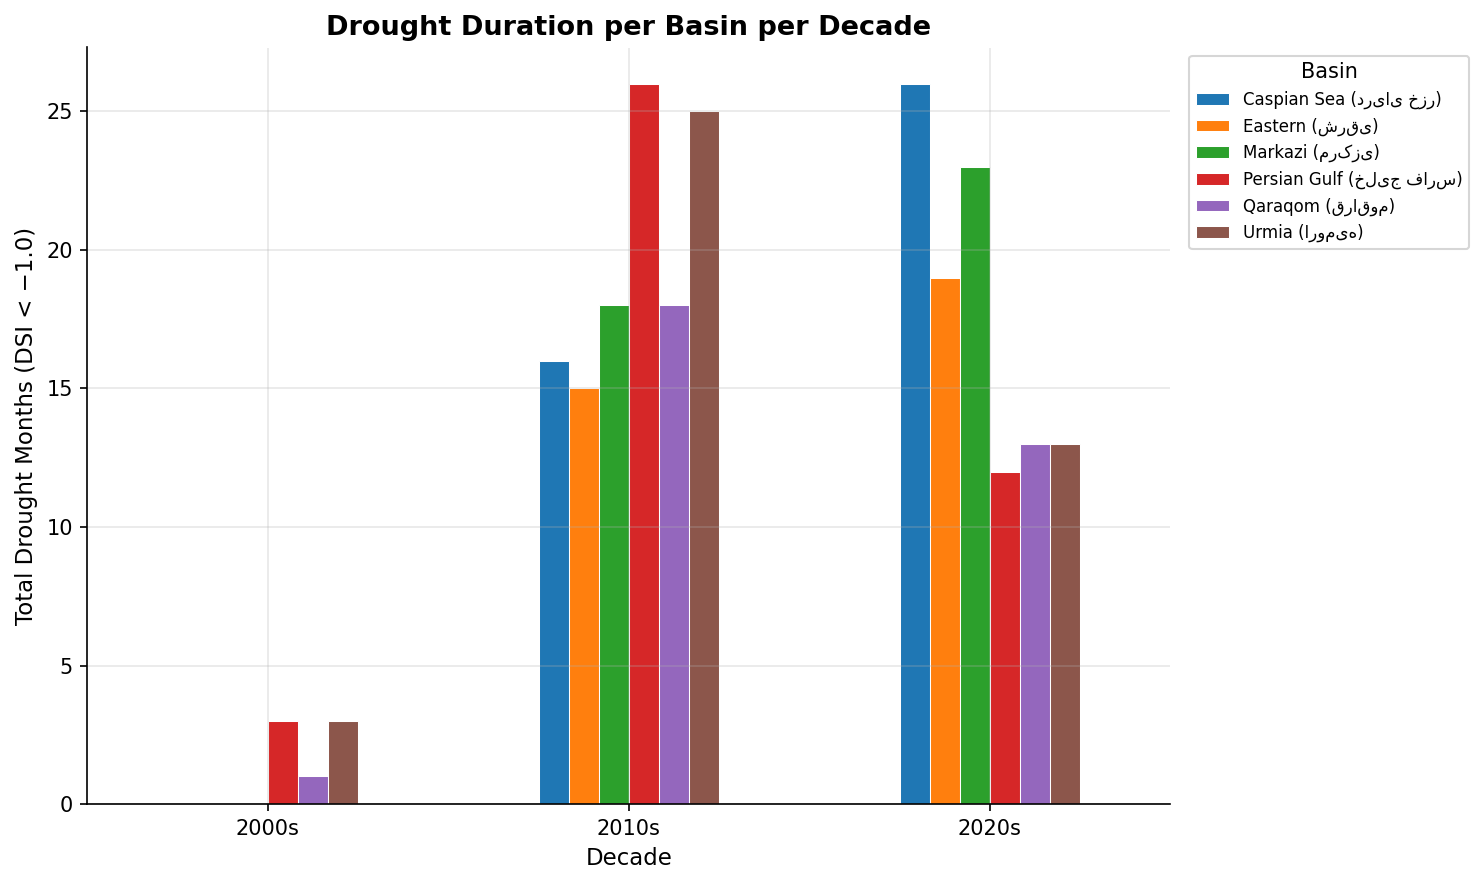

Plot saved: outputs/drought_frequency_decade.png


In [14]:
# Visualize: stacked bar — drought months per basin per decade
decade_rows = []
for basin in BASINS:
    for ep in all_episodes[basin]:
        yr = int(ep['start'][:4])
        decade = f'{(yr // 10) * 10}s'
        decade_rows.append({'basin': BASIN_LABELS[basin], 'decade': decade,
                            'months': ep['duration_months']})

if decade_rows:
    decade_df = pd.DataFrame(decade_rows).groupby(['basin','decade'])['months'].sum().unstack(fill_value=0)
    colors_d = [BASIN_COLORS[b] for b in BASINS]

    fig, ax = plt.subplots(figsize=(10, 6))
    decade_df.T.plot(kind='bar', ax=ax, color=colors_d, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Decade', fontsize=11)
    ax.set_ylabel('Total Drought Months (DSI < −1.0)', fontsize=11)
    ax.set_title('Drought Duration per Basin per Decade', fontsize=13, fontweight='bold')
    ax.legend(title='Basin', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'drought_frequency_decade.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Plot saved: outputs/drought_frequency_decade.png')


### توضیحات خروجی
<div dir="rtl">

از تجزیه فصلی مشخص شد که مؤلفه روند (trend component) در اکثر حوضه‌ها کاهشی است، که این با نتایج رگرسیون خطی همخوانی دارد.

جداول دوره‌های خشکسالی تاریخچه‌ای دقیق از رویدادهای مهم ارائه می‌دهند — این اطلاعات مستقیماً وارد جدول ۴.۳ فصل چهارم پایان‌نامه می‌شود.

نکته: دوره‌های طولانی‌تر و DSI پایین‌تر، شدت بیشتر خشکسالی را نشان می‌دهند.

</div>


---
## فاز ۵: مقایسه حوضه‌ها

### Phase 5 — Spatial / Basin Comparison

Here we compare the 6 basins side-by-side using:
- Mean TWSA (overall water storage level)
- Variance (stability)
- GRACE-DSI statistics
- Ranking by drought vulnerability


In [15]:
# Basin comparison table
comp_rows = []
for basin in BASINS:
    twsa   = grace[basin]
    dsi_s  = dsi[basin]
    ep_sum = ep_summary[ep_summary['Basin'] == BASIN_LABELS[basin]].iloc[0]

    comp_rows.append({
        'Basin': BASIN_LABELS[basin],
        'Mean TWSA (cm)': round(twsa.mean(), 2),
        'Std TWSA (cm)':  round(twsa.std(), 2),
        'Min TWSA (cm)':  round(twsa.min(), 2),
        'Max TWSA (cm)':  round(twsa.max(), 2),
        'Mean DSI':       round(dsi_s.mean(), 3),
        'Min DSI':        round(dsi_s.min(), 3),
        'Drought episodes': ep_sum['Episodes'],
        'Total drought months': ep_sum['Total drought months'],
    })

comp_df = pd.DataFrame(comp_rows).set_index('Basin')
print('Basin Comparison:')
print(comp_df.to_string())

comp_df.to_csv(OUTPUT_DIR / 'basin_comparison.csv')
print('\nSaved to outputs/basin_comparison.csv')


Basin Comparison:
                          Mean TWSA (cm)  Std TWSA (cm)  Min TWSA (cm)  Max TWSA (cm)  Mean DSI  Min DSI  Drought episodes  Total drought months
Basin                                                                                                                                           
Caspian Sea (دریای خزر)            -6.44          13.45         -42.91          18.19       0.0   -2.712                 7                    42
Eastern (شرقی)                     -1.12           4.30         -15.65          20.47       0.0   -3.380                20                    34
Qaraqom (قراقوم)                   -0.53           5.08         -14.28          15.62       0.0   -2.704                20                    32
Markazi (مرکزی)                    -2.09           5.75         -17.61          13.29       0.0   -2.697                13                    41
Persian Gulf (خلیج فارس)           -1.09           6.97         -16.23          17.00      -0.0   -2.171        

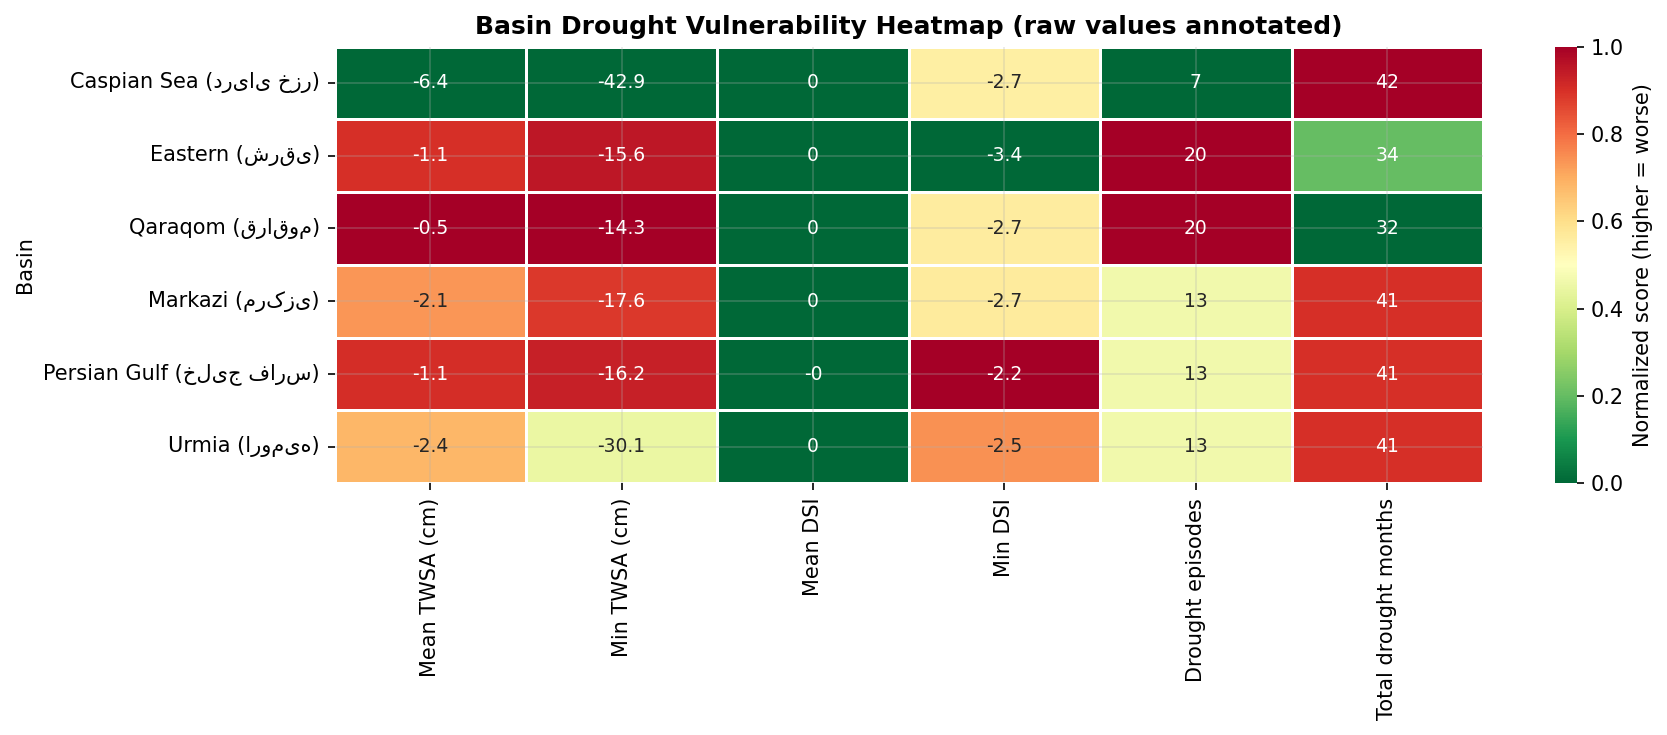

Plot saved: outputs/basin_comparison_heatmap.png


In [16]:
# Heatmap: normalized basin metrics
fig, ax = plt.subplots(figsize=(12, 5))

heat_data = comp_df[['Mean TWSA (cm)', 'Min TWSA (cm)', 'Mean DSI', 'Min DSI',
                       'Drought episodes', 'Total drought months']].copy()

# Normalize each column so all metrics are on the same scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heat_norm = pd.DataFrame(
    scaler.fit_transform(heat_data),
    index=heat_data.index,
    columns=heat_data.columns
)

sns.heatmap(heat_norm, annot=heat_data.round(1), fmt='g',
            cmap='RdYlGn_r', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalized score (higher = worse)'},
            annot_kws={'size': 9})

ax.set_title('Basin Drought Vulnerability Heatmap (raw values annotated)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'basin_comparison_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print('Plot saved: outputs/basin_comparison_heatmap.png')


In [17]:
# Also load station metadata to show geographic coverage
stations = pd.read_excel(DATA_DIR / 'synopticdatanew2.xlsx', engine='openpyxl')
stations = stations[stations['watershed_name'] != 'خارج از حوزه‌ها'].copy()

station_counts = stations.groupby('watershed_name').agg(
    stations_count=('station_na', 'count'),
    provinces=('province', lambda x: ', '.join(sorted(x.unique())))
).reset_index()
station_counts.columns = ['Watershed', 'Station count', 'Provinces covered']
print('Station coverage per watershed:')
print(station_counts.to_string(index=False))


Station coverage per watershed:
  Watershed  Station count                                                                                                                                                                                   Provinces covered
Caspian Sea             44                        Alborz, Ardebil, Azarbayjan-e-Gharbi, Azarbayjan-e-Sharghi, Gilan, Golestan, Hamedan, Khorasan Razavi, Kordestan, Mazandaran, North Khorasan, Qazvin, Semnan, Tehran, Zanjan
    eastern              8                                                                                                                                              Khorasan Razavi, Sistan Va Baluchestan, South Khorasan
    markazi             61 Chaharmahal Va Bakhtiari, Esfahan, Fars, Hamedan, Hormozgan, Kerman, Khorasan Razavi, Kohgiluyeh Va Boyerahmad, Lorestan, Markazi, Qom, Semnan, Sistan Va Baluchestan, South Khorasan, Tehran, Yazd
persiangolf             50                                                  

### توضیحات خروجی
<div dir="rtl">

جدول مقایسه حوضه‌ها و نقشه گرمایی، آسیب‌پذیرترین حوضه‌ها در برابر خشکسالی را مشخص می‌کنند.
این اطلاعات برای بخش ۴.۶ (تحلیل مکانی) فصل چهارم مورد استفاده قرار می‌گیرد.

تعداد ایستگاه‌های هر حوضه نشان می‌دهد که شبکه پایش در فاز ۲ (پس از دریافت داده اقلیمی) چقدر خوب است.

</div>


---
## فاز ۶: پیش‌بینی کوتاه‌مدت (ARIMA + زنجیره مارکوف)

### Phase 6 — Short-Term Forecasting

**Method 1 — ARIMA:** Fit an ARIMA model on each basin's TWSA and forecast 24 months ahead.

**Method 2 — Markov Chain:** Model drought state transitions.
States: `Wet (DSI ≥ 0)` | `Near-normal (-1 ≤ DSI < 0)` | `Moderate (-1.5 ≤ DSI < -1)` | `Severe (DSI < -1.5)`

Reference: *پایش و پیش‌بینی خشکسالی ماهانه با استفاده از زنجیره مارکوف* (cited in proposal)


In [18]:
# ARIMA forecasting — 24 months ahead for each basin
# We'll use ARIMA(1,1,1) as a reasonable starting point;
# could be optimised with auto_arima but keeping it simple for now.

arima_forecasts = {}
forecast_horizon = 24

for basin in BASINS:
    series = grace[basin].dropna()
    try:
        model  = ARIMA(series, order=(1, 1, 1))
        fitted = model.fit()
        fc     = fitted.forecast(steps=forecast_horizon)
        ci     = fitted.get_forecast(steps=forecast_horizon).conf_int(alpha=0.10)
        arima_forecasts[basin] = {'forecast': fc, 'ci': ci, 'fitted': fitted}
    except Exception as e:
        print(f'ARIMA failed for {basin}: {e}')

print(f'ARIMA fitted for {len(arima_forecasts)} basins.')


E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was p

ARIMA fitted for 6 basins.


E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\projects\drought_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was p

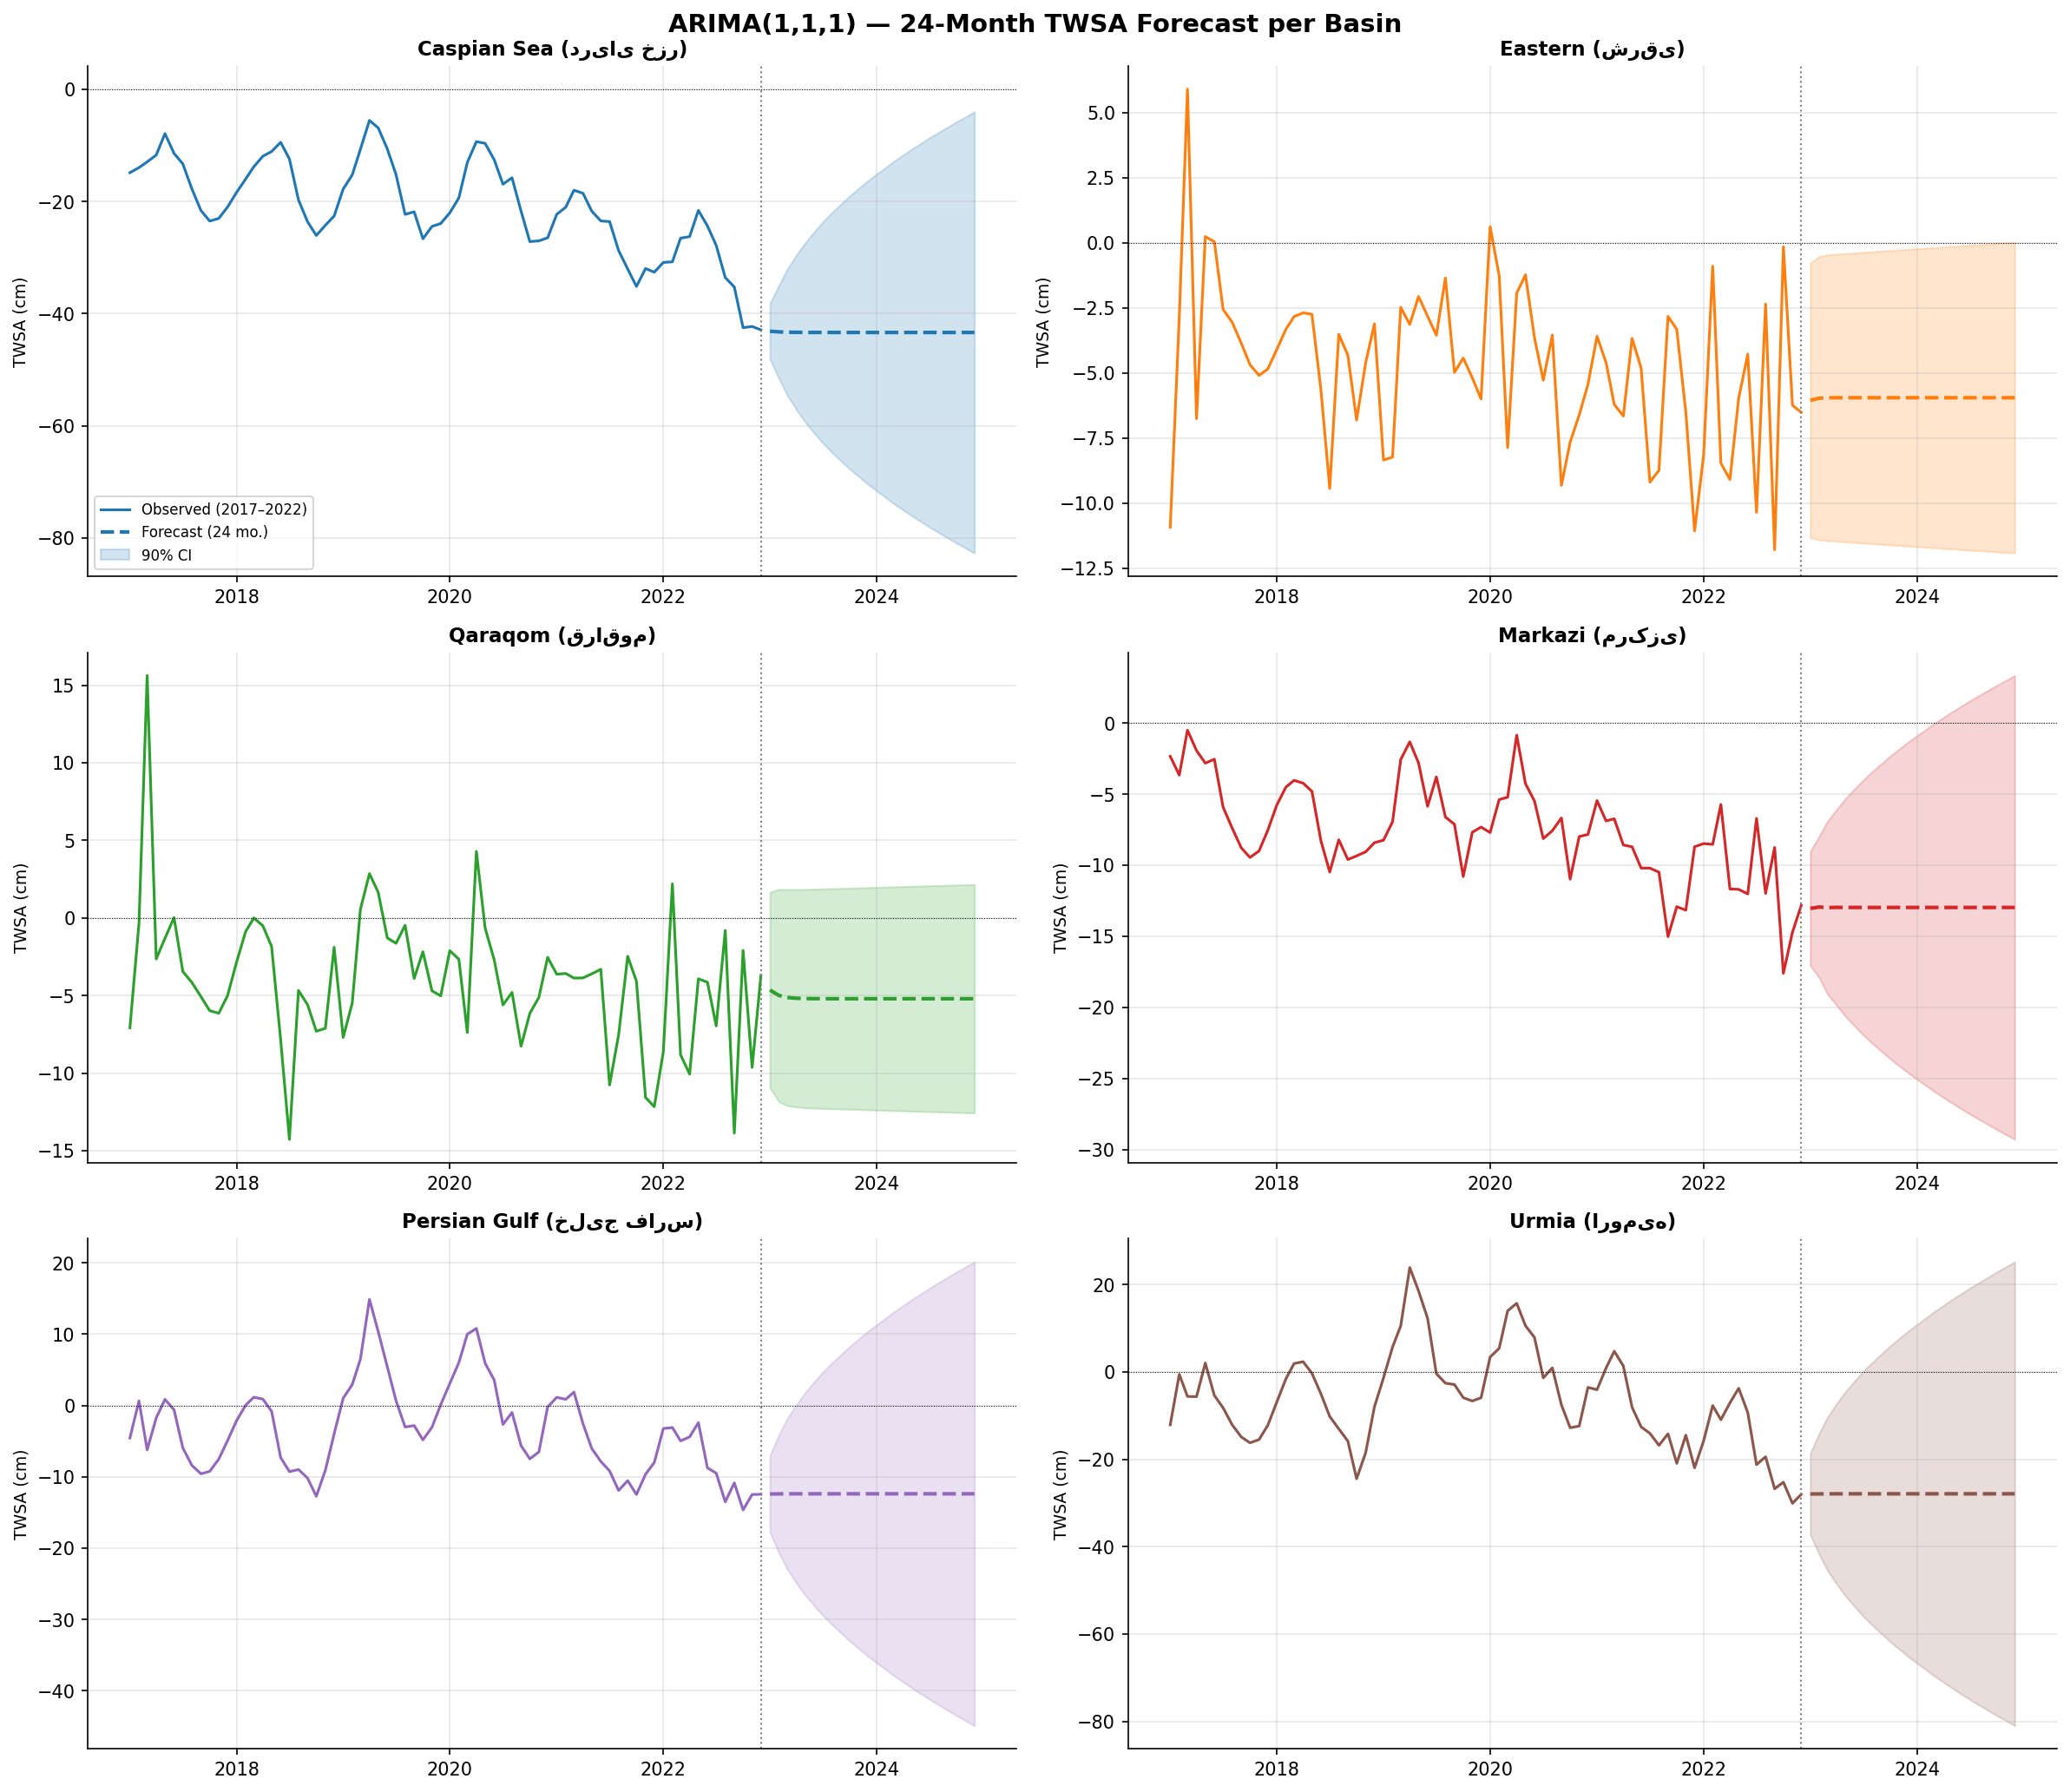

Plot saved: outputs/arima_forecasts.png


In [19]:
# Plot ARIMA forecasts — show last 5 years of history + 24-month forecast
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, basin in enumerate(BASINS):
    ax = axes[idx]
    series = grace[basin].dropna()

    # Show only last 5 years of historical data for clarity
    history = series[series.index >= '2017-01-01']

    # Build future date index
    last_date = series.index[-1]
    future_idx = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=forecast_horizon, freq='MS'
    )

    if basin in arima_forecasts:
        fc  = arima_forecasts[basin]['forecast']
        ci  = arima_forecasts[basin]['ci']
        fc.index = future_idx
        ci.index = future_idx

        ax.plot(history.index, history.values, color=BASIN_COLORS[basin],
                linewidth=1.5, label='Observed (2017–2022)')
        ax.plot(future_idx, fc.values, color=BASIN_COLORS[basin],
                linewidth=2, linestyle='--', label='Forecast (24 mo.)')
        ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                        alpha=0.20, color=BASIN_COLORS[basin], label='90% CI')
        ax.axvline(last_date, color='gray', linewidth=1, linestyle=':')

    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax.set_title(BASIN_LABELS[basin], fontsize=11, fontweight='bold')
    ax.set_ylabel('TWSA (cm)', fontsize=9)
    if idx == 0:
        ax.legend(fontsize=8)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('ARIMA(1,1,1) — 24-Month TWSA Forecast per Basin',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arima_forecasts.png', bbox_inches='tight', dpi=300)
plt.show()
print('Plot saved: outputs/arima_forecasts.png')


In [20]:
# Markov chain drought state transitions
# States: 0=Wet, 1=Near-normal, 2=Moderate, 3=Severe/Extreme
STATE_LABELS = {0: 'Wet', 1: 'Near-normal', 2: 'Moderate', 3: 'Severe/Extreme'}

def dsi_to_state(val):
    if pd.isna(val): return np.nan
    if val >= 0:     return 0
    if val >= -1.0:  return 1
    if val >= -1.5:  return 2
    return 3

mc_results = {}

for basin in BASINS:
    states = dsi[basin].apply(dsi_to_state).dropna().astype(int)
    n = 4

    # Build transition count matrix
    trans_count = np.zeros((n, n), dtype=int)
    for i in range(len(states) - 1):
        trans_count[states.iloc[i], states.iloc[i+1]] += 1

    # Normalise rows → probability matrix
    row_sums = trans_count.sum(axis=1, keepdims=True)
    trans_prob = np.divide(trans_count, row_sums, where=row_sums > 0)

    mc_results[basin] = {'count': trans_count, 'prob': trans_prob}

    print(f'\n{BASIN_LABELS[basin]} — Transition Probability Matrix:')
    prob_df = pd.DataFrame(trans_prob.round(3),
                           index=[STATE_LABELS[i] for i in range(n)],
                           columns=[STATE_LABELS[i] for i in range(n)])
    print(prob_df.to_string())



Caspian Sea (دریای خزر) — Transition Probability Matrix:
                  Wet  Near-normal  Moderate  Severe/Extreme
Wet             0.936        0.064     0.000           0.000
Near-normal     0.090        0.821     0.090           0.000
Moderate        0.000        0.231     0.615           0.154
Severe/Extreme  0.000        0.000     0.200           0.800

Eastern (شرقی) — Transition Probability Matrix:
                  Wet  Near-normal  Moderate  Severe/Extreme
Wet             0.808        0.160     0.024           0.008
Near-normal     0.209        0.605     0.093           0.093
Moderate        0.188        0.438     0.188           0.188
Severe/Extreme  0.118        0.412     0.176           0.294

Qaraqom (قراقوم) — Transition Probability Matrix:
                  Wet  Near-normal  Moderate  Severe/Extreme
Wet             0.739        0.244     0.000           0.017
Near-normal     0.247        0.559     0.108           0.086
Moderate        0.176        0.529     0.176     

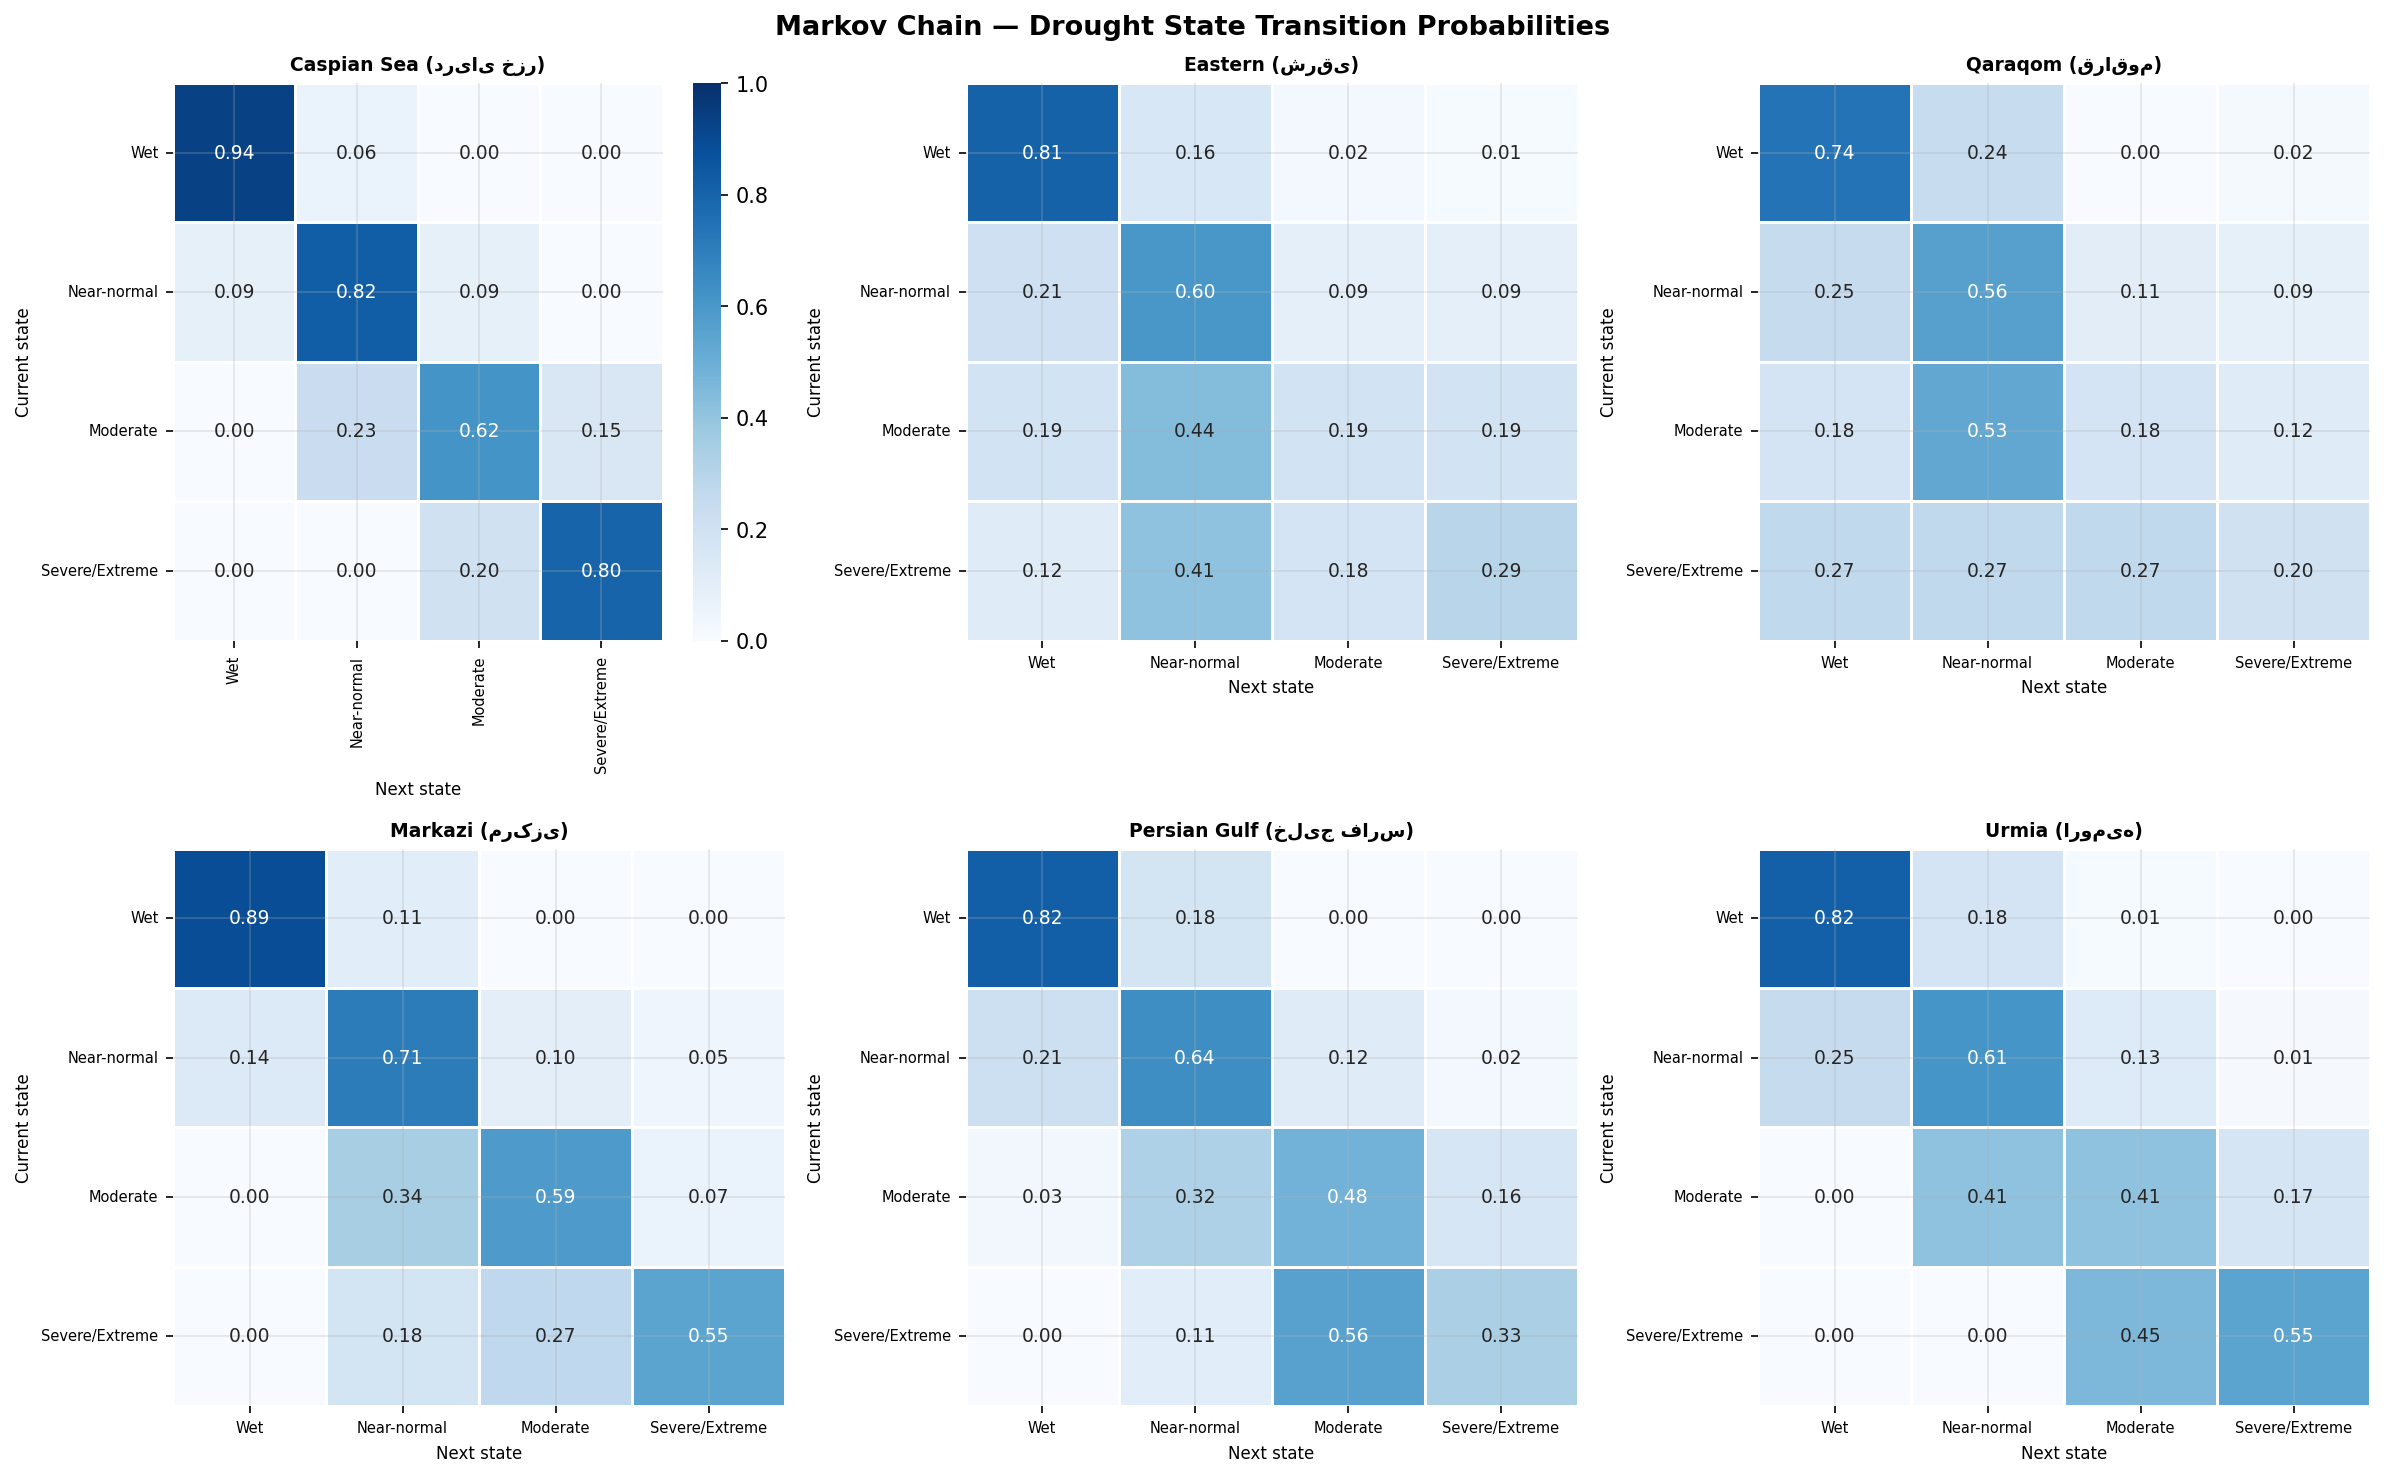

Plot saved: outputs/markov_transition_matrices.png


In [21]:
# Plot Markov transition matrices as heatmaps (one per basin, 2-row grid)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, basin in enumerate(BASINS):
    ax = axes[idx]
    prob = mc_results[basin]['prob']
    state_names = [STATE_LABELS[i] for i in range(4)]

    sns.heatmap(prob, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=state_names, yticklabels=state_names,
                linewidths=0.5, ax=ax, vmin=0, vmax=1,
                annot_kws={'size': 9}, cbar=idx == 0)

    ax.set_title(BASIN_LABELS[basin], fontsize=9, fontweight='bold')
    ax.set_xlabel('Next state', fontsize=8)
    ax.set_ylabel('Current state', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Markov Chain — Drought State Transition Probabilities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'markov_transition_matrices.png', bbox_inches='tight', dpi=300)
plt.show()
print('Plot saved: outputs/markov_transition_matrices.png')


In [22]:
# Steady-state drought probability for each basin
print('Steady-state (long-run) drought probabilities per basin:')
print(f'{"Basin":<35}  {"Wet":>8}  {"Near-norm":>10}  {"Moderate":>10}  {"Severe":>10}')
print('-' * 80)

for basin in BASINS:
    P = mc_results[basin]['prob']
    # eigenvector of P^T corresponding to eigenvalue 1
    eigvals, eigvecs = np.linalg.eig(P.T)
    # find the eigenvector closest to eigenvalue 1
    idx_eig = np.argmin(np.abs(eigvals - 1))
    ss = np.real(eigvecs[:, idx_eig])
    ss = ss / ss.sum()
    print(f'{BASIN_LABELS[basin]:<35}  {ss[0]:>8.3f}  {ss[1]:>10.3f}  {ss[2]:>10.3f}  {ss[3]:>10.3f}')


Steady-state (long-run) drought probabilities per basin:
Basin                                     Wet   Near-norm    Moderate      Severe
--------------------------------------------------------------------------------
Caspian Sea (دریای خزر)                 0.454       0.324       0.126       0.097
Eastern (شرقی)                          0.501       0.356       0.071       0.071
Qaraqom (قراقوم)                        0.480       0.388       0.071       0.062
Markazi (مرکزی)                         0.456       0.360       0.128       0.056
Persian Gulf (خلیج فارس)                0.452       0.366       0.136       0.045
Urmia (ارومیه)                          0.466       0.348       0.128       0.058


### توضیحات خروجی
<div dir="rtl">

**ARIMA**: پیش‌بینی ۲۴ ماهه بر اساس الگوهای تاریخی. فاصله اطمینان ۹۰٪ نشان می‌دهد که پیش‌بینی چقدر قابل اطمینان است.

**زنجیره مارکوف**: ماتریس احتمال انتقال نشان می‌دهد که از هر وضعیت، چه احتمالی برای رفتن به حالت‌های دیگر وجود دارد.
- سطر «Severe/Extreme»: اگر احتمال ماندن در همین وضعیت بالا باشد، خشکسالی پایدار است.
- توزیع پایا (Steady-state): بیانگر درصد وقتی است که هر حوضه در بلندمدت در هر وضعیت خشکسالی می‌گذراند.

</div>


---
## فاز ۷: خلاصه نتایج فاز ۱

### Phase 7 — Summary & Chapter 4 Ready-Text

This section consolidates all Phase 1 findings into a structured summary that maps directly to Chapter 4 sections of the thesis.


In [23]:
# Final consolidated summary printout
print('=' * 70)
print('PHASE 1 ANALYSIS SUMMARY')
print('=' * 70)

print('\n[4.1] DATA OVERVIEW')
print(f'  GRACE time range: {grace.index.min().strftime("%b %Y")} → {grace.index.max().strftime("%b %Y")} ({len(grace)} months)')
print(f'  Basins: {len(BASINS)}')
print(f'  Variable: TWSA (cm) — Total Water Storage Anomaly')

print('\n[4.3] GRACE-DSI — Extreme drought months (DSI < -2.0) per basin:')
for basin in BASINS:
    extreme = (dsi[basin] < -2.0).sum()
    print(f'  {BASIN_LABELS[basin]}: {extreme} months')

print('\n[4.4] TREND ANALYSIS — Linear slope (cm/year) and significance:')
for _, row in trend_df.iterrows():
    direction = 'DECLINING' if row['Slope (cm/yr)'] < 0 else 'INCREASING'
    print(f'  {row["Basin"]}: {row["Slope (cm/yr)"]:+.3f} cm/yr ({direction}, MK: {row["MK significance"]})')

print('\n[4.5] DROUGHT EPISODES — Most severe per basin:')
for basin in BASINS:
    eps = all_episodes[basin]
    if eps:
        worst = min(eps, key=lambda e: e['min_DSI'])
        print(f'  {BASIN_LABELS[basin]}: worst episode {worst["start"]}–{worst["end"]}, DSI={worst["min_DSI"]}')
    else:
        print(f'  {BASIN_LABELS[basin]}: no prolonged drought episodes detected')

print('\n[4.8] FORECASTING:')
print(f'  ARIMA(1,1,1) 24-month forecasts generated for all basins.')
print(f'  Markov chain transition matrices computed and steady-state probabilities derived.')

print('\n[4.9] OUTPUTS SAVED:')
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f'  {f.name}')


PHASE 1 ANALYSIS SUMMARY

[4.1] DATA OVERVIEW
  GRACE time range: Aug 2002 → Dec 2022 (245 months)
  Basins: 6
  Variable: TWSA (cm) — Total Water Storage Anomaly

[4.3] GRACE-DSI — Extreme drought months (DSI < -2.0) per basin:
  Caspian Sea (دریای خزر): 6 months
  Eastern (شرقی): 5 months
  Qaraqom (قراقوم): 7 months
  Markazi (مرکزی): 3 months
  Persian Gulf (خلیج فارس): 1 months
  Urmia (ارومیه): 4 months

[4.4] TREND ANALYSIS — Linear slope (cm/year) and significance:
  Caspian Sea (دریای خزر): -2.043 cm/yr (DECLINING, MK: ***)
  Eastern (شرقی): -0.472 cm/yr (DECLINING, MK: ***)
  Qaraqom (قراقوم): -0.535 cm/yr (DECLINING, MK: ***)
  Markazi (مرکزی): -0.840 cm/yr (DECLINING, MK: ***)
  Persian Gulf (خلیج فارس): -0.602 cm/yr (DECLINING, MK: ***)
  Urmia (ارومیه): -0.977 cm/yr (DECLINING, MK: ***)

[4.5] DROUGHT EPISODES — Most severe per basin:
  Caspian Sea (دریای خزر): worst episode 2021-05–2022-12 (ongoing), DSI=-2.71
  Eastern (شرقی): worst episode 2016-11–2017-02, DSI=-3.38
  

### توضیحات خروجی
<div dir="rtl">

## ✅ فاز ۱ با موفقیت تکمیل شد

تمام خروجی‌های مورد نیاز برای بخش‌های ۴.۱ تا ۴.۵ و ۴.۸ فصل چهارم تولید شدند.

**گام بعدی — فاز ۲:**
برای تکمیل فرضیه سوم پروپوزال (H3)، باید داده‌های بارندگی ماهانه از منابع GPCC، CRU یا GHCN دانلود شوند.
سپس می‌توان:
- شاخص SPI را محاسبه کرد
- همبستگی GRACE-DSI با SPI را آزمون کرد
- تأخیر زمانی GRACE نسبت به بارش را بررسی کرد

</div>

---

> **Phase 2 will be implemented in `drought_analysis_phase2.ipynb`** once meteorological precipitation data is acquired.
